# Solving a HANK Model with the Sequence-Space Jacobian Method

- Author: Yuxuan Zhao
- Date: 2026-08-12

This notebook solves a one-asset
heterogeneous-agent New Keynesian (HANK) model using the sequence-space
Jacobian (SSJ) method. 


## 1) Model

Time is discrete. There is a unit mass of heterogeneous households and a unit
mass of monopolistically competitive intermediate-goods firms. Households can
self-insure only by holding one-period nominal government bonds. There is no
physical capital. Firms produce with labor and face Rotemberg price-adjustment
costs. Monetary policy follows a Taylor rule, while fiscal policy keeps the real
supply of government debt constant.

The aggregate exogenous variables are log total factor productivity and the
log monetary-policy shock,

$$
E=(\log z,\eta),
$$

and the sequence-space unknowns are gross inflation, the real wage, and output,

$$
U=(\Pi,w,Y).
$$

For a transition horizon $T$, these symbols denote complete paths:

$$
\begin{aligned}
\Pi&=(\Pi_0,\ldots,\Pi_{T-1}),\\
w&=(w_0,\ldots,w_{T-1}),\\
Y&=(Y_0,\ldots,Y_{T-1}),\\
\log z&=(\log z_0,\ldots,\log z_{T-1}),\\
\eta&=(\eta_0,\ldots,\eta_{T-1}).
\end{aligned}
$$

The perfect-foresight transition starts from the deterministic steady-state
household distribution and inherited nominal interest rate. Beyond date $T-1$,
all aggregate variables are set back to their deterministic steady-state
values. These initial and terminal conditions are part of the finite-horizon
approximation and will be made explicit in the code.

### 1.1 Fundamental shocks

Idiosyncratic efficiency and the two aggregate shocks follow independent AR(1)
processes:

$$
\begin{aligned}
\log e_{i,t+1}
&=\rho_e\log e_{i,t}+\varepsilon^e_{i,t+1},\\
\log z_{t+1}
&=\rho_z\log z_t+\varepsilon^z_{t+1},\\
\eta_{t+1}
&=\rho_\eta\eta_t+\varepsilon^\eta_{t+1}.
\end{aligned}
$$

Idiosyncratic risk remains stochastic in the SSJ household problem. We
approximate $e$ by a finite-state Markov chain with transition matrix $P_e$:

$$
\Pr(e_{t+1}=e'\mid e_t=e)=P_e(e,e').
$$

An SSJ experiment takes a particular aggregate shock path as given. Thus
households have perfect foresight about the aggregate path during the
transition but continue to face idiosyncratic uncertainty.

### 1.2 Household problem in unshifted bonds

Let $b_t$ denote the real value of nominal government bonds carried into date
$t$. The household budget constraint is

$$
c_t+b_{t+1}
=R_tb_t+w_te_tn_t+d_t+T_t,
\qquad b_{t+1}\geq0,
$$

where

- $c_t$ is consumption;
- $n_t$ is hours worked;
- $e_t$ is idiosyncratic labor efficiency;
- $R_t$ is the gross realized real return on bonds purchased previously;
- $w_t$ is the real wage per efficiency unit;
- $d_t$ is an equal per-capita dividend; and
- $T_t$ is a lump-sum fiscal transfer.

Preferences are

$$
u(c,n)=\log c-\frac{n^2}{2},
$$

so the household maximizes

$$
\mathbb E_0\sum_{t=0}^{\infty}\beta^t
\left(\log c_t-\frac{n_t^2}{2}\right).
$$


### 1.3 Fiscal policy and household bonds

The government keeps the real supply of one-period bonds fixed at $B$. Its
period budget constraint is

$$
B=R_tB+T_t,
$$

so the lump-sum transfer is

$$
T_t=(1-R_t)B.
$$

We keep the household's bond position in its original, unshifted form. The
individual borrowing constraint is therefore

$$
b_{t+1}\geq0.
$$

If $D_t(e,b)$ is the beginning-of-date household distribution, aggregate bond
demand chosen at date $t$ is

$$
B_{t+1}^{H}
=\int b_{t+1}(e,b)\,dD_t(e,b).
$$

Bond-market clearing requires $B_{t+1}^{H}=B$. Keeping $T_t$ explicit makes
the fiscal-transfer channel visible in both the transition block and the
household Jacobians.


### 1.4 Recursive household problem along a transition path

In a deterministic SSJ transition, the complete aggregate path is given. The
household still faces idiosyncratic efficiency risk, so only $e_{t+1}$ remains
inside the expectation.

#### Terminal stationary problem

For $t\geq T$, aggregate variables are fixed at their deterministic
steady-state values:

$$
(R_t,w_t,d_t,T_t)=(R_{ss},w_{ss},d_{ss},T_{ss}).
$$

The terminal value is the stationary household value function

$$
\begin{aligned}
V_{ss}(e,b)
=\max_{c,n,b'}\quad&
\log c-\frac{n^2}{2}
+\beta\sum_{e'}P_e(e,e')V_{ss}(e',b')\\
\text{s.t.}\quad&
c+b'=R_{ss}b+w_{ss}en+d_{ss}+T_{ss},\\
&b'\geq0,\qquad c>0.
\end{aligned}
$$

Solving this problem gives terminal marginal utility $u_{c,ss}=1/c_{ss}$,
the stationary bond policy $g_{ss}$, and the invariant distribution $D_{ss}$.

#### Household problem during the finite transition

Given a candidate aggregate path

$$
\mathcal P
=\{R_t,w_t,d_t,T_t\}_{t=0}^{T},
$$

with terminal values equal to the deterministic steady state, the recursive
problem for $t=0,\ldots,T-1$ is

$$
\begin{aligned}
V_t(e,b;\mathcal P)
=\max_{c,n,b'}\quad&
\log c-\frac{n^2}{2}
+\beta\sum_{e'}P_e(e,e')V_{t+1}(e',b';\mathcal P)\\
\text{s.t.}\quad&
c+b'=R_tb+w_ten+d_t+T_t,\\
&b'\geq0,\qquad c>0,
\end{aligned}
$$

with terminal condition

$$
V_T(e,b;\mathcal P)=V_{ss}(e,b).
$$

The individual recursive state is $(t,e,b)$. Calendar time records the
household's position along the known aggregate path; the cross-sectional
distribution is not an individual state once prices are given.

#### Backward policies and forward distribution

Starting from $V_T=V_{ss}$, backward induction produces

$$
\{g_t,c_t,n_t\}_{t=0}^{T-1}.
$$

The transition begins from

$$
D_0=D_{ss}.
$$

Given the date-$t$ bond policy, the distribution evolves according to

$$
D_{t+1}(e',\mathcal B)
=
\sum_eP_e(e,e')
\int
\mathbf 1\{g_t(e,b)\in\mathcal B\}\,dD_t(e,b)
$$

for every bond set $\mathcal B$. Aggregate household quantities are

$$
\begin{aligned}
B_{t+1}^{H}
&=\sum_e\int g_t(e,b)\,dD_t(e,b),\\
C_t
&=\sum_e\int c_t(e,b)\,dD_t(e,b),\\
NE_t
&=\sum_e\int e\,n_t(e,b)\,dD_t(e,b).
\end{aligned}
$$

The finite-horizon approximation imposes $V_T=V_{ss}$, or equivalently the
terminal marginal-utility condition used by EGM. It does not impose
$D_T=D_{ss}$; the terminal distribution distance is reported later.

### 1.5 Competitive final-good producer

A competitive final-good producer combines a continuum of differentiated intermediate goods with a CES technology:

$$
Y_t
=\left[
\int_0^1 y_{j,t}^{\frac{\epsilon-1}{\epsilon}}dj
\right]^{\frac{\epsilon}{\epsilon-1}},
\qquad \epsilon>1.
$$

Cost minimization problem is:

$$
\begin{aligned}
\min_{y_{j,t}}\int_0^1p_{j,t}y_{j,t}dj \quad\text{s.t.}\quad \\
Y_t
=\left[
\int_0^1 y_{j,t}^{\frac{\epsilon-1}{\epsilon}}dj
\right]^{\frac{\epsilon}{\epsilon-1}}.
\end{aligned}
$$

 implies the aggregate price index and demand for variety $j$:

$$
P_t
=\left[
\int_0^1p_{j,t}^{1-\epsilon}dj
\right]^{\frac{1}{1-\epsilon}},
\qquad
y_{j,t}
=\left(\frac{p_{j,t}}{P_t}\right)^{-\epsilon}Y_t.
$$


### 1.6 Intermediate firms and current profits

Intermediate firm $j$ produces with labor only:

$$
y_{j,t}=z_t\ell_{j,t},
\qquad
\ell_{j,t}
=\frac{1}{z_t}
\left(\frac{p_{j,t}}{P_t}\right)^{-\epsilon}Y_t.
$$

It inherits last period's price $p_{j,t-1}$ and pays a Rotemberg cost when changing its price. Measured in units of the final good, current profits are

$$
\mathcal D_{j,t}
=\left[
\left(\frac{p_{j,t}}{P_t}\right)^{1-\epsilon}
-\frac{w_t}{z_t}
\left(\frac{p_{j,t}}{P_t}\right)^{-\epsilon}
-\frac{\kappa}{2}
\left(\frac{p_{j,t}}{p_{j,t-1}}-1\right)^2
\right]Y_t.
$$

A larger $\kappa$ makes prices more rigid; when $\kappa=0$, prices are flexible.

#### Dynamic price setting along the deterministic transition

In the SSJ problem, the entire aggregate transition path

$$
\mathcal Q
=\{P_\tau,w_\tau,z_\tau,Y_\tau\}_{\tau=0}^{T}
$$

is given to the firm once and for all. There is no perceived law of motion and
no expectation over future aggregate shocks. Conditional on the inherited
price $p_{j,t-1}$, at every date $t=0,\ldots,T-1$ firm $j$ solves

$$
W_t(p_{j,t-1};\mathcal Q)
=
\max_{p_{j,t}}
\left\{
\mathcal D_{j,t}
+\beta_FW_{t+1}(p_{j,t};\mathcal Q)
\right\},
\qquad
W_T=W_{ss}.
$$

The terminal continuation uses steady-state inflation and output. In the
Julia transition block this is implemented by setting
$\Pi_T=\Pi_{ss}$ and $Y_T=Y_{ss}$.

#### From the pricing FOC to the nonlinear NKPC

The price $p_{j,t}$ affects current demand and the current Rotemberg cost, and
it also enters next period's adjustment rate $p_{j,t+1}/p_{j,t}$. The
date-$t$ pricing FOC is

$$
0
=
\frac{p_{j,t}}{Y_t}
\left[
\frac{\partial\mathcal D_{j,t}}{\partial p_{j,t}}
+\beta_F
\frac{\partial W_{t+1}}{\partial p_{j,t}}
\right].
$$

To evaluate the two derivatives, define

$$
q_{j,t}\equiv\frac{p_{j,t}}{P_t},
\qquad
x_{j,t}\equiv\frac{p_{j,t}}{p_{j,t-1}},
\qquad
mc_t\equiv\frac{w_t}{z_t}.
$$

Differentiating current revenue, the wage bill, and the current adjustment
cost gives

$$
\frac{p_{j,t}}{Y_t}
\frac{\partial\mathcal D_{j,t}}{\partial p_{j,t}}
=
(1-\epsilon)q_{j,t}^{\,1-\epsilon}
+\epsilon mc_tq_{j,t}^{-\epsilon}
-\kappa(x_{j,t}-1)x_{j,t}.
$$

By the envelope theorem, the inherited price $p_{j,t}$ affects
$W_{t+1}$ only through next period's adjustment cost. Hence

$$
\frac{p_{j,t}}{Y_t}
\frac{\partial W_{t+1}}{\partial p_{j,t}}
=
\frac{Y_{t+1}}{Y_t}
\kappa(x_{j,t+1}-1)x_{j,t+1}.
$$

Substituting these two expressions into the pricing FOC gives the individual
firm's condition

$$
\begin{aligned}
0={}&
(1-\epsilon)q_{j,t}^{\,1-\epsilon}
+\epsilon mc_tq_{j,t}^{-\epsilon}
-\kappa(x_{j,t}-1)x_{j,t}\\
&+\beta_F\frac{Y_{t+1}}{Y_t}
\kappa(x_{j,t+1}-1)x_{j,t+1}.
\end{aligned}
$$

Now impose symmetry only at the end:

$$
\frac{p_{j,t}}{P_t}=1,
\qquad
\frac{p_{j,t}}{p_{j,t-1}}=\Pi_t,
\qquad
\frac{p_{j,t+1}}{p_{j,t}}=\Pi_{t+1}.
$$

This gives the deterministic transition-path NKPC

$$
\boxed{
(1-\epsilon)+\epsilon\frac{w_t}{z_t}
-\kappa(\Pi_t-1)\Pi_t
+\beta_F\frac{Y_{t+1}}{Y_t}
\kappa(\Pi_{t+1}-1)\Pi_{t+1}
=0.
}
$$

This expression has no conditional expectation over aggregate shocks because
the future aggregate path is already fixed when the transition is evaluated.
When $\kappa=0$, it reduces to

$$
\frac{w_t}{z_t}=\frac{\epsilon-1}{\epsilon}.
$$

#### Dividends and resource costs

In symmetric equilibrium, aggregate real revenue is $Y_t$, the wage bill is $\frac{w_t}{z_t}Y_t$, and Rotemberg costs absorb final goods. Per-capita dividends are therefore

$$
d_t
=\left[
1-\frac{w_t}{z_t}
-\frac{\kappa}{2}(\Pi_t-1)^2
\right]Y_t.
$$

Thus price adjustment costs affect both firm pricing and the resources distributed to households. They are treated as real resource costs in the model solved below.

### 1.7 Monetary policy and Fisher timing

The central bank chooses the gross nominal payoff on bonds purchased at date
$t$ according to

$$
1+i_t
=\bar R\Pi_t^{\varphi_\pi}\exp(\eta_t).
$$

The gross real return realized at date $t$ is the inherited nominal payoff
divided by current gross inflation:

$$
R_t=\frac{1+i_{t-1}}{\Pi_t}.
$$

Thus a monetary shock at date $t$ directly changes $i_t$, but this payoff enters
the household budget as $R_{t+1}$ at date $t+1$. Current inflation changes the
real value of the nominal payoff inherited from date $t-1$. The implementation
must preserve both channels.


### 1.8 Market clearing and the reduced equilibrium system

#### Aggregate household variables

Let $D_t(e,b)$ be the distribution of households at the beginning of date
$t$. Given policies

$$
b_{t+1}=g_t(e,b),
\qquad
c_t=c_t(e,b),
\qquad
n_t=n_t(e,b),
$$

define aggregate bond demand, consumption, and efficiency-weighted labor:

$$
\begin{aligned}
B_{t+1}^{H}
&=\int g_t(e,b)\,dD_t(e,b),\\
C_t
&=\int c_t(e,b)\,dD_t(e,b),\\
NE_t
&=\int e\,n_t(e,b)\,dD_t(e,b).
\end{aligned}
$$

The timing is important: $B_{t+1}^{H}$ is chosen at date $t$, whereas $C_t$
and $NE_t$ are current-date quantities.

#### Market-clearing conditions

The bond market clears when household bond demand equals the fixed government
debt supply:

$$
B_{t+1}^{H}=B.
$$

In symmetric equilibrium, intermediate-firm labor demand is

$$
L_t=\frac{Y_t}{z_t}.
$$

Households supply $NE_t$ efficiency units, so labor-market clearing requires

$$
NE_t=L_t=\frac{Y_t}{z_t}.
$$

Rotemberg adjustment costs absorb final goods. Goods-market clearing is

$$
Y_t=C_t+\frac{\kappa}{2}(\Pi_t-1)^2Y_t.
$$

Firm optimality additionally requires the nonlinear NKPC derived above.

#### Residual definitions

Define

$$
\begin{aligned}
H_t^{NKPC}
\equiv{}&
(1-\epsilon)+\epsilon\frac{w_t}{z_t}
-\kappa(\Pi_t-1)\Pi_t\\
&+\beta_F\frac{Y_{t+1}}{Y_t}
\kappa(\Pi_{t+1}-1)\Pi_{t+1},\\[0.4em]
H_t^B
\equiv{}&B_{t+1}^{H}-B,\\
H_t^N
\equiv{}&NE_t-\frac{Y_t}{z_t},\\
H_t^G
\equiv{}&Y_t-C_t-\frac{\kappa}{2}(\Pi_t-1)^2Y_t.
\end{aligned}
$$

The first three residuals are the solver targets. Stacking dates by residual
block gives

$$
H(U;E)
\equiv
\begin{bmatrix}
H^{NKPC}\\
H^B\\
H^N
\end{bmatrix}
\in\mathbb R^{3T},
\qquad
H(U;E)=0.
$$

The goods-market residual is retained as an independent numerical diagnostic.
Walras' law implies $H^G=0$ when the household budget, government budget,
bond market, and labor market are implemented consistently.


## 2) Julia Setup

The setup cell locates the repository root, activates the pinned Julia project,
loads the required packages, and includes `src/SSJ_Function.jl`.

Model equations and equilibrium blocks remain in the notebook. Reusable
numerical, reporting, MPC/HtM, parameter-sweep, and DAG helpers live in the
source file.


In [1]:
using Pkg

function find_project_root(start_dir=pwd())
    dir = abspath(start_dir)
    while true
        isfile(joinpath(dir, "Project.toml")) && return dir
        parent = dirname(dir)
        parent == dir && error("Could not find Project.toml from $(start_dir)")
        dir = parent
    end
end

project_root = find_project_root()
Pkg.activate(project_root)

using LinearAlgebra
using Printf
using Plots
using Plots.PlotMeasures

include(joinpath(project_root, "src", "SSJ_Function.jl"))

default(
    linewidth=2,
    framestyle=:box,
    legend=:best,
    gridalpha=0.25,
    size=(1000, 600),
    left_margin=10mm,
    right_margin=5mm,
    bottom_margin=9mm,
    top_margin=5mm,
    guidefontsize=11,
    tickfontsize=9,
    titlefontsize=12,
)

  Activating project at `C:\Users\30945\Desktop\Yuxuan ZHAO\minnesota\Research\sequence_space_jacobian`


## 3) Transition Blocks and DAG

For a finite horizon $T$, define the unknown and exogenous sequence vectors

$$
U=
\begin{bmatrix}
\Pi\\w\\Y
\end{bmatrix}
\in\mathbb R^{3T},
\qquad
E=
\begin{bmatrix}
\log z\\\eta
\end{bmatrix}
\in\mathbb R^{2T}.
$$

For any candidate paths $(U,E)$, the transition evaluator works through five
blocks. The arrows in the DAG show objects passed between blocks; they do not
indicate additional equilibrium unknowns.

### 3.1 Monetary and Fisher block

**Input:** $(\Pi,\eta)$ and the inherited payoff $J_{-1}=J_{ss}$.

$$
J_t\equiv1+i_t
=\bar R\Pi_t^{\varphi_\pi}\exp(\eta_t),
\qquad
R_t=\frac{J_{t-1}}{\Pi_t}.
$$

**Output:** the gross nominal-payoff path $J$ and realized gross real-return
path $R$. The lag in the Fisher equation preserves the timing of nominal bonds.

### 3.2 Fiscal block

**Input:** $R$ and the fixed government debt supply $B$.

$$
T_t=(1-R_t)B.
$$

**Output:** the lump-sum transfer path $T$. This block makes the fiscal channel
explicit instead of eliminating it through an asset shift.

### 3.3 Firm block

**Input:** $(\Pi,w,Y,\log z)$.

$$
z_t=e^{\log z_t},
\qquad
L_t=\frac{Y_t}{z_t},
\qquad
\Phi_t=\frac{\kappa}{2}(\Pi_t-1)^2Y_t,
\qquad
d_t=Y_t-w_tL_t-\Phi_t.
$$

**Output:** labor demand $L$, dividends $d$, and Rotemberg resource costs
$\Phi$. The firm block does not output $H^{NKPC}$.

### 3.4 Household transition block

**Input:** $(R,w,d,T)$, the terminal marginal utility $u_{c,ss}$, and the
initial distribution $D_0=D_{ss}$.

Backward EGM solves policies from $t=T-1$ to $0$ under

$$
c_t+b_{t+1}=R_tb_t+w_te_tn_t+d_t+T_t,
\qquad b_{t+1}\geq0.
$$

The distribution is then propagated forward from $D_0$. 

**Output:** household
bond demand $B^+$, consumption $C$, efficiency labor $NE$, and
$(D_1,\ldots,D_T)$.

### 3.5 Equilibrium residual block

The residual block receives $(\Pi,w,Y,z)$ directly, $L$ from the firm block,
and $(B^+,NE)$ from the household block. It computes

$$
H_t(U;E)=
\begin{bmatrix}
H_t^{NKPC}(\Pi,w,Y,z)\\
B_{t+1}^{H}-B\\
NE_t-L_t
\end{bmatrix}.
$$

Thus the NKPC is evaluated as an equilibrium residual, not as a firm-block
output. The root solver adjusts $(\Pi,w,Y)$ until all $3T$ residuals are zero.
The goods-market gap $Y-C-\Phi$ is returned only as a diagnostic.

### Initial conditions

$$
D_0=D_{ss},
\qquad
J_{-1}=J_{ss}.
$$

### Terminal conditions

$$
u_{c,T}=u_{c,ss},
\qquad
R_T=R_{ss},
\qquad
\Pi_T=\Pi_{ss},
\qquad
Y_T=Y_{ss}.
$$

These conditions approximate a return to the deterministic steady state beyond
the truncation horizon. No terminal restriction is imposed on $D_T$.


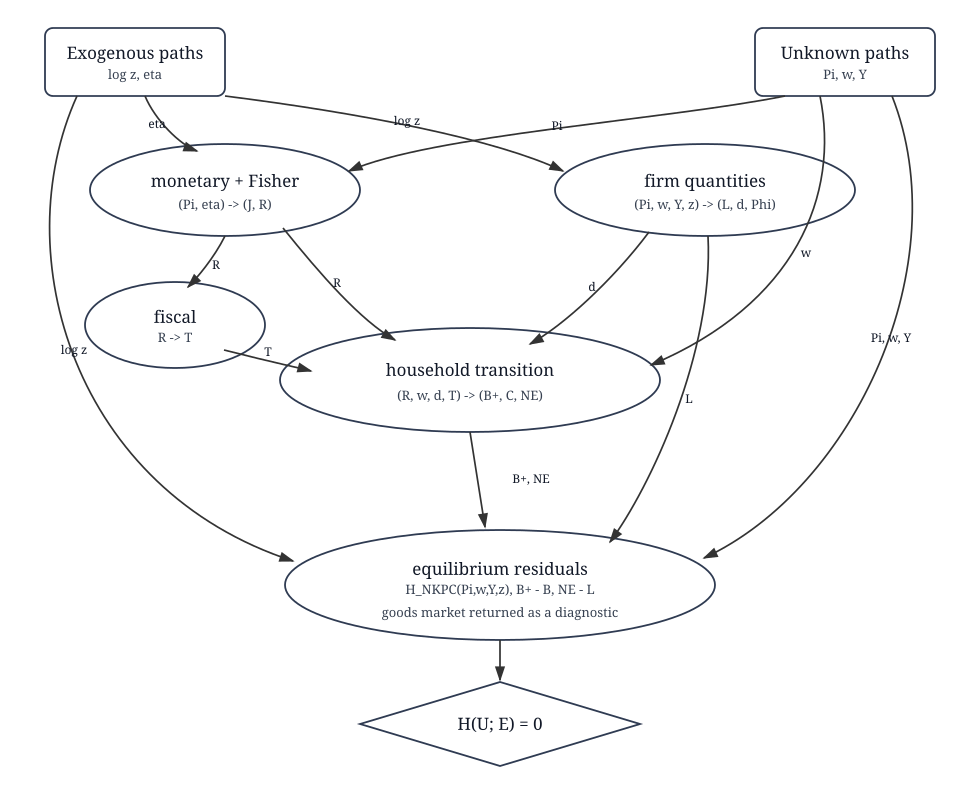

In [2]:
InlineSVG(hank_dag_svg())

## 4) Calibration and State Grids

The structural calibration used in the SSJ exercise is:

| Parameter | Value | Meaning |
|---|---:|---|
| $\beta$ | 0.975 | household discount factor |
| $\beta_F$ | 0.975 | firm discount factor in the NKPC |
| $\epsilon$ | 10 | elasticity of substitution across varieties |
| $\kappa$ | 100 | Rotemberg price-adjustment cost |
| $\varphi_\pi$ | 1.5 | Taylor-rule response to inflation |
| $\bar R$ | $0.997/0.975$ | Taylor-rule gross-rate intercept |
| $B$ | 2 | real government debt supply |
| $(\rho_e,\sigma_e)$ | $(0.6,0.16)$ | idiosyncratic log-efficiency process |
| $(\rho_z,\sigma_z)$ | $(0.9,0.07\sqrt{1-0.9^2})$ | log TFP process |
| $(\rho_\eta,\sigma_\eta)$ | $(0.9,0.002\sqrt{1-0.9^2})$ | monetary shock process |

The household block uses a 300-node quadratic grid for unshifted bond holdings:

$$
b_j=b_{max}x_j^2,
\qquad x_j\in[0,1],
\qquad b_j\in[0,b_{max}].
$$

The lower endpoint is exactly the borrowing constraint $b=0$. The quadratic
transformation places more nodes near that endpoint, where saving and
consumption policies are most curved. The upper bound $b_{max}$ is a numerical
parameter and is not the government debt supply $B$.


In [3]:
Base.@kwdef struct SSJHANKParams
    beta::Float64 = 0.975
    firm_beta::Float64 = 0.975
    substitution_elasticity::Float64 = 10.0
    rotemberg_cost::Float64 = 100.0
    taylor_inflation::Float64 = 1.5
    taylor_target::Float64 = 0.997 / 0.975
    debt::Float64 = 2.0

    rho_e::Float64 = 0.6
    sigma_e::Float64 = 0.16
    nE::Int = 3

    rho_z::Float64 = 0.9
    sigma_z::Float64 = 0.07 * sqrt(1 - 0.9^2)
    rho_eta::Float64 = 0.9
    sigma_eta::Float64 = 0.002 * sqrt(1 - 0.9^2)

    nB::Int = 300
    bond_max::Float64 = 100.0
end

params = SSJHANKParams()

println("Borrowing limit       = 0.0")
println("Bond-grid upper bound = ", params.bond_max)
println("Government debt       = ", params.debt)
println("Household discount    = ", params.beta)
println("Rotemberg cost        = ", params.rotemberg_cost)
println("Taylor coefficient    = ", params.taylor_inflation)
println("TFP innovation sd     = ", params.sigma_z)
println("Monetary innovation sd= ", params.sigma_eta)


Borrowing limit       = 0.0
Bond-grid upper bound = 

100.0
Government debt       = 2.0
Household discount    = 0.975
Rotemberg cost        = 100.0
Taylor coefficient    = 1.5
TFP innovation sd     = 0.030512292604784712
Monetary innovation sd= 0.0008717797887081345


### 4.1 Tauchen discretization of idiosyncratic efficiency

The continuous process is

$$
\log e_{t+1}=\rho_e\log e_t+\varepsilon^e_{t+1},
\qquad
\varepsilon^e_{t+1}\sim N(0,\sigma_e^2).
$$

Its unconditional standard deviation is

$$
\sigma_{\log e}=\frac{\sigma_e}{\sqrt{1-\rho_e^2}}.
$$

Tauchen's method places `nE` log-efficiency nodes between
$-3\sigma_{\log e}$ and $3\sigma_{\log e}$. Transition probabilities are
normal probabilities that next period's latent log efficiency falls inside the
interval associated with each grid point.

After constructing the transition matrix $P_e$, we compute its invariant
distribution $\pi_e$ and normalize efficiency levels so that

$$
\sum_e\pi_e(e)e=1.
$$

This normalization makes $NE$ directly interpretable as aggregate efficiency
units of labor.

In [4]:
function normal_cdf(x::Real)
    ax = abs(Float64(x))
    t = 1.0 / (1.0 + 0.2316419 * ax)
    density = 0.3989422804014327 * exp(-0.5 * ax^2)
    tail = density * t * (
        0.319381530 + t * (-0.356563782 + t * (
        1.781477937 + t * (-1.821255978 + t * 1.330274429)))
    )
    cdf = 1.0 - tail
    return x >= 0 ? cdf : 1.0 - cdf
end

function tauchen(n::Int, rho::Float64, sigma_innovation::Float64;
                 width::Float64=3.0)
    sigma_stationary = sigma_innovation / sqrt(1 - rho^2)
    log_grid = collect(range(
        -width * sigma_stationary,
        width * sigma_stationary;
        length=n,
    ))
    grid_step = log_grid[2] - log_grid[1]
    transition = zeros(n, n)

    for i in 1:n, j in 1:n
        conditional_mean = rho * log_grid[i]
        if j == 1
            transition[i, j] = normal_cdf(
                (log_grid[1] + grid_step / 2 - conditional_mean) /
                sigma_innovation
            )
        elseif j == n
            transition[i, j] = 1 - normal_cdf(
                (log_grid[n] - grid_step / 2 - conditional_mean) /
                sigma_innovation
            )
        else
            upper = (log_grid[j] + grid_step / 2 - conditional_mean) /
                    sigma_innovation
            lower = (log_grid[j] - grid_step / 2 - conditional_mean) /
                    sigma_innovation
            transition[i, j] = normal_cdf(upper) - normal_cdf(lower)
        end
    end
    transition ./= sum(transition; dims=2)
    return log_grid, transition
end

function make_ssj_hank_grid(params::SSJHANKParams)
    nodes = collect(range(0.0, 1.0; length=params.nB)) .^ 2
    b_grid = params.bond_max .* nodes

    log_e_grid, Pi_e = tauchen(
        params.nE, params.rho_e, params.sigma_e
    )
    pi_e = stationary_markov(Pi_e)
    raw_e = exp.(log_e_grid)
    e_grid = raw_e ./ dot(pi_e, raw_e)
    return (; b_grid, log_e_grid, e_grid, pi_e, Pi_e)
end

grids = make_ssj_hank_grid(params)
println("Bond nodes        = ", length(grids.b_grid))
println("Bond-grid support = [", first(grids.b_grid), ", ", last(grids.b_grid), "]")
println("Efficiency levels = ", round.(grids.e_grid; digits=5))
println("Invariant weights = ", round.(grids.pi_e; digits=5))
println("Transition row sums error = ",
    maximum(abs.(vec(sum(grids.Pi_e; dims=2)) .- 1)))


Bond nodes        = 300
Bond-grid support = [0.0, 100.0]


Efficiency levels = [0.53428, 0.97353, 1.77388]
Invariant weights = [0.07331, 0.85337, 0.07331]
Transition row sums error = 0.0


## 5) Solve the Household Problem by the Endogenous-Grid Method

The household is the only heterogeneous block. This section derives exactly
what the two Julia functions below compute.

### 5.1 Euler inequality and the interior EGM branch

The backward object is next period's marginal utility,

$$
u_{c,t+1}(e',b')=\frac{1}{c_{t+1}(e',b')}.
$$

For a proposed next-period bond position $b'$,

$$
\mathbb E_t[u_{c,t+1}\mid e,b']
=\sum_{e'}P_e(e,e')u_{c,t+1}(e',b').
$$

The saving condition is

$$
\frac{1}{c_t}
\geq
\beta R_{t+1}
\sum_{e'}P_e(e,e')u_{c,t+1}(e',b').
$$

EGM first constructs the equality branch:

$$
c_t^{\mathrm{int}}(e,b')
=
\left[
\beta R_{t+1}
\sum_{e'}P_e(e,e')u_{c,t+1}(e',b')
\right]^{-1},
\qquad
n_t^{\mathrm{int}}(e,b')
=\frac{w_te}{c_t^{\mathrm{int}}(e,b')}.
$$

At $b'=0$, this equality construction locates the cutoff between interior and
borrowing-constrained households.

### 5.2 Endogenous current-bond grid

Substitute $(c,n,b')$ into

$$
c+b'=R_tb+w_ten+d_t+T_t.
$$

The current bond holding that supports the choice is

$$
b^{endo}(e,b')
=\frac{c(e,b')+b'-w_ten(e,b')-d_t-T_t}{R_t}.
$$

For each efficiency state, linear interpolation maps the saving policy from
this endogenous current-bond grid back to the fixed $b$ grid.

### 5.3 Borrowing-constrained branch

If $b\leq b^{endo}_{min}(e)$, the policy is set to

$$
b'=0.
$$

Define current nonlabor resources net of saving as

$$
q=R_tb+d_t+T_t-b'.
$$

Combining the binding budget constraint with $n=w_te/c$ gives

$$
c=\frac{q+\sqrt{q^2+4(w_te)^2}}{2},
\qquad
n=\frac{w_te}{c}.
$$

The Julia code uses the algebraically equivalent stable expression when
$q<0$.

### 5.4 One backward step: inputs and outputs

The function `ssj_hank_egm_step` takes

$$
(u_{c,t+1},R_t,R_{t+1},w_t,d_t,T_t)
$$

and returns

$$
(u_{c,t},g_t,c_t,n_t).
$$

$R_t$ enters today's cash on hand, whereas $R_{t+1}$ enters the Euler equation
for bonds carried forward.

### 5.5 Stationary household fixed point

At a stationary price vector,

$$
R_t=R_{t+1}=R,
\qquad
(w_t,d_t,T_t)=(w,d,T).
$$

We iterate the backward EGM map until marginal utility stops changing. Given
the stationary bond policy, we iterate the distribution transition operator
until $D=\Lambda(g,P_e)D$, then aggregate bond holdings, consumption, and
efficiency-weighted labor.


In [5]:
function ssj_household_choices(nonlabor_resources::Real, effective_wage::Real)
    q = max(Float64(effective_wage)^2, 1e-20)
    resources = Float64(nonlabor_resources)
    root = sqrt(resources^2 + 4q)
    consumption = resources >= 0 ?
        0.5 * (resources + root) : 2q / (root - resources)
    consumption = max(consumption, 1e-10)
    labor = effective_wage / consumption
    return consumption, labor
end

function ssj_hank_egm_step(
    marginal_utility_next,
    b_grid,
    e_grid,
    Pi_e,
    gross_return,
    gross_return_next,
    wage,
    dividend,
    transfer,
    beta,
)
    expected_mu = Pi_e * marginal_utility_next
    nE, nB = length(e_grid), length(b_grid)
    marginal_utility = similar(marginal_utility_next)
    b_policy = similar(marginal_utility_next)
    c_policy = similar(marginal_utility_next)
    n_policy = similar(marginal_utility_next)

    for ie in 1:nE
        effective_wage = wage * e_grid[ie]
        c_endogenous = 1.0 ./ (
            beta * gross_return_next .* expected_mu[ie, :]
        )
        n_endogenous = effective_wage ./ c_endogenous
        b_endogenous = (
            c_endogenous .+ b_grid .-
            effective_wage .* n_endogenous .- dividend .- transfer
        ) ./ gross_return

        for ib in 1:nB
            current_bonds = b_grid[ib]
            b_next = current_bonds <= b_endogenous[1] ?
                b_grid[1] :
                interp_linear(b_endogenous, b_grid, current_bonds)
            consumption, labor = ssj_household_choices(
                gross_return * current_bonds + dividend + transfer - b_next,
                effective_wage,
            )
            b_policy[ie, ib] = b_next
            c_policy[ie, ib] = consumption
            n_policy[ie, ib] = labor
            marginal_utility[ie, ib] = 1 / consumption
        end
    end
    return (; marginal_utility, b_policy, c_policy, n_policy)
end


ssj_hank_egm_step (generic function with 1 method)

In [6]:
function solve_ssj_household_steady_state(
    gross_return,
    wage,
    dividend,
    transfer,
    grids,
    params::SSJHANKParams;
    tolerance=1e-11,
    max_iterations=10_000,
)
    b_grid, e_grid, Pi_e = grids.b_grid, grids.e_grid, grids.Pi_e
    marginal_utility = zeros(length(e_grid), length(b_grid))

    for ie in eachindex(e_grid), ib in eachindex(b_grid)
        consumption, _ = ssj_household_choices(
            gross_return * b_grid[ib] + dividend + transfer - b_grid[1],
            wage * e_grid[ie],
        )
        marginal_utility[ie, ib] = 1 / consumption
    end

    for iteration in 1:max_iterations
        updated = ssj_hank_egm_step(
            marginal_utility,
            b_grid,
            e_grid,
            Pi_e,
            gross_return,
            gross_return,
            wage,
            dividend,
            transfer,
            params.beta,
        )
        error_value = maximum(abs.(
            log.(updated.marginal_utility) .- log.(marginal_utility)
        ))
        marginal_utility = updated.marginal_utility

        if error_value < tolerance
            distribution = stationary_distribution(
                updated.b_policy, b_grid, Pi_e; tol=1e-13
            )
            effective_labor = reshape(e_grid, :, 1) .* updated.n_policy
            return (;
                updated...,
                distribution,
                B=sum(distribution .* updated.b_policy),
                C=sum(distribution .* updated.c_policy),
                NE=sum(distribution .* effective_labor),
                iterations=iteration,
                error=error_value,
            )
        end
    end
    error("Stationary household EGM did not converge.")
end


solve_ssj_household_steady_state (generic function with 1 method)

## 6) Deterministic Steady State

The steady-state unknowns are

$$
x_{ss}=(\Pi_{ss},w_{ss},Y_{ss}).
$$

At $z=1$, the aggregate blocks imply

$$
J=\bar R\Pi^{\varphi_\pi},\qquad
R=J/\Pi,\qquad
T=(1-R)B,\qquad
d=\left[1-w-\frac{\kappa}{2}(\Pi-1)^2\right]Y.
$$

The household solution gives bond demand $B^H(x)$ and effective labor $NE(x)$. We solve

$$
F(x)=
\begin{bmatrix}
(1-\epsilon)+\epsilon w-(1-\beta_F)\kappa(\Pi-1)\Pi\\
B^H(x)-B\\
NE(x)-Y
\end{bmatrix}
=0.
$$

The goods-market residual
$Y-C-\frac{\kappa}{2}(\Pi-1)^2Y$ is reported as an untargeted check.


In [7]:
struct SSJHANKSteadyState
    inflation::Float64
    wage::Float64
    output::Float64
    gross_nominal_rate::Float64
    gross_return::Float64
    transfer::Float64
    dividend::Float64
    consumption::Float64
    effective_labor::Float64
    bond_holdings::Float64
    bond_residual::Float64
    nkpc_residual::Float64
    labor_residual::Float64
    goods_residual::Float64
    policy_iterations::Int
    b_grid::Vector{Float64}
    e_grid::Vector{Float64}
    pi_e::Vector{Float64}
    Pi_e::Matrix{Float64}
    marginal_utility::Matrix{Float64}
    b_policy::Matrix{Float64}
    c_policy::Matrix{Float64}
    n_policy::Matrix{Float64}
    distribution::Matrix{Float64}
end

function steady_state_evaluation(x, grids, params::SSJHANKParams)
    inflation, wage, output = x
    gross_nominal_rate = params.taylor_target *
        inflation^params.taylor_inflation
    gross_return = gross_nominal_rate / inflation
    transfer = (1 - gross_return) * params.debt
    dividend = (
        1 - wage -
        0.5 * params.rotemberg_cost * (inflation - 1)^2
    ) * output
    household = solve_ssj_household_steady_state(
        gross_return, wage, dividend, transfer, grids, params
    )
    nkpc = (1 - params.substitution_elasticity) +
        params.substitution_elasticity * wage -
        (1 - params.firm_beta) * params.rotemberg_cost *
        (inflation - 1) * inflation
    residual = [nkpc, household.B - params.debt, household.NE - output]
    return residual, (;
        inflation, wage, output, gross_nominal_rate, gross_return,
        transfer, dividend, household,
    )
end

function compute_ssj_hank_steady_state(grids, params::SSJHANKParams)
    x = [0.9985855568642088, 0.9025679191630948, 0.9756634991318448]

    for _ in 1:25
        residual, _ = steady_state_evaluation(x, grids, params)
        maximum(abs.(residual)) < 1e-9 && break
        jacobian = finite_difference_jacobian_at(
            y -> first(steady_state_evaluation(y, grids, params)),
            x;
            h=1e-5,
        )
        direction = -(jacobian \ residual)
        step_length = 1.0
        accepted = false

        for _ in 1:25
            candidate = x + step_length * direction
            feasible = 0.90 < candidate[1] < 1.10 &&
                       candidate[2] > 0.20 && candidate[3] > 0.20
            if feasible
                candidate_residual, _ = steady_state_evaluation(
                    candidate, grids, params
                )
                if maximum(abs.(candidate_residual)) < maximum(abs.(residual))
                    x = candidate
                    accepted = true
                    break
                end
            end
            step_length *= 0.5
        end
        accepted || error("Steady-state Newton step did not improve residuals.")
    end

    residual, objects = steady_state_evaluation(x, grids, params)
    maximum(abs.(residual)) < 1e-8 || error("Steady state did not converge.")
    hh = objects.household
    adjustment_cost = 0.5 * params.rotemberg_cost *
        (objects.inflation - 1)^2 * objects.output
    goods_residual = objects.output - hh.C - adjustment_cost

    return SSJHANKSteadyState(
        objects.inflation,
        objects.wage,
        objects.output,
        objects.gross_nominal_rate,
        objects.gross_return,
        objects.transfer,
        objects.dividend,
        hh.C,
        hh.NE,
        hh.B,
        residual[2],
        residual[1],
        residual[3],
        goods_residual,
        hh.iterations,
        grids.b_grid,
        grids.e_grid,
        grids.pi_e,
        grids.Pi_e,
        hh.marginal_utility,
        hh.b_policy,
        hh.c_policy,
        hh.n_policy,
        hh.distribution,
    )
end

ss = compute_ssj_hank_steady_state(grids, params)

println("Deterministic HANK steady state")
println(repeat("-", 50))
@printf("%-28s %16.10f\n", "gross inflation", ss.inflation)
@printf("%-28s %16.10f\n", "real wage", ss.wage)
@printf("%-28s %16.10f\n", "output", ss.output)
@printf("%-28s %16.10f\n", "gross real return", ss.gross_return)
@printf("%-28s %16.10f\n", "fiscal transfer", ss.transfer)
@printf("%-28s %16.10f\n", "household bonds", ss.bond_holdings)
@printf("%-28s %16.10f\n", "consumption", ss.consumption)
@printf("%-28s %16.3e\n", "bond residual", ss.bond_residual)
@printf("%-28s %16.3e\n", "labor residual", ss.labor_residual)
@printf("%-28s %16.3e\n", "goods residual", ss.goods_residual)
@printf("%-28s %16d\n", "EGM iterations", ss.policy_iterations)


Deterministic HANK steady state
--------------------------------------------------
gross inflation                  0.9946620235
real wage                        0.8986726294
output                           0.9643812844
gross real return                1.0198312391
fiscal transfer                 -0.0396624783
household bonds                  2.0000000001
consumption                      0.9630073308


bond residual                       6.667e-11
labor residual                     -6.743e-13
goods residual                     -1.533e-12


EGM iterations                            383


The steady state solves the NKPC, bond market, and labor market jointly. All targeted residuals and the untargeted goods-market residual should be close to zero.


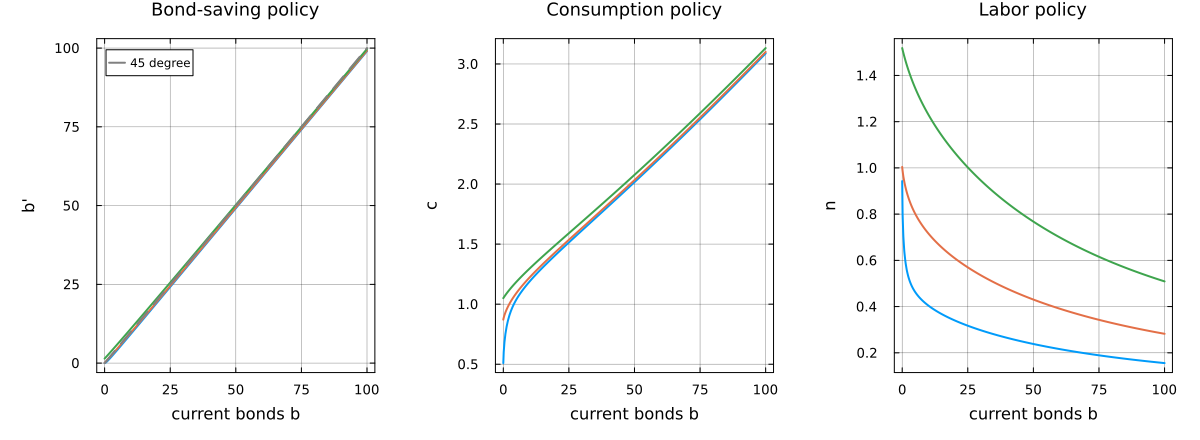

In [8]:
p_saving = plot(
    ss.b_grid,
    ss.b_policy',
    title="Bond-saving policy",
    xlabel="current bonds b",
    ylabel="b'",
    label=false,
)
plot!(p_saving, ss.b_grid, ss.b_grid;
    color=:gray, linestyle=:dash, label="45 degree")

p_consumption = plot(
    ss.b_grid,
    ss.c_policy',
    title="Consumption policy",
    xlabel="current bonds b",
    ylabel="c",
    label=false,
)

p_labor = plot(
    ss.b_grid,
    ss.n_policy',
    title="Labor policy",
    xlabel="current bonds b",
    ylabel="n",
    label=false,
)

plot(p_saving, p_consumption, p_labor; layout=(1, 3), size=(1200, 440))


Saving rises with current bond holdings; consumption rises and labor falls with wealth. The three curves correspond to the discrete efficiency states.


## 7) Transition-Block Implementation

### 7.1 Aggregate blocks

For $t=0,\ldots,T-1$:

1. **Monetary and Fisher block**
   $$
   J_t=\bar R\Pi_t^{\varphi_\pi}e^{\eta_t},
   \qquad
   R_t=\frac{J_t^{lag}}{\Pi_t},
   \qquad
   J^{lag}=(J_{ss},J_0,\ldots,J_{T-2}).
   $$

2. **Fiscal block**
   $$
   T_t=(1-R_t)B.
   $$

3. **Firm quantities**
   $$
   z_t=e^{\log z_t},\qquad
   L_t=Y_t/z_t,\qquad
   \Phi_t=\frac{\kappa}{2}(\Pi_t-1)^2Y_t,\qquad
   d_t=Y_t-w_tL_t-\Phi_t.
   $$

4. **Pricing residual**

   The NKPC is evaluated in the residual block using
   $\Pi^{lead}=(\Pi_1,\ldots,\Pi_{T-1},\Pi_{ss})$ and the analogous
   $Y^{lead}$.


In [9]:
lag_path(x, initial_value) = vcat(initial_value, x[1:end-1])
lead_path(x, terminal_value) = vcat(x[2:end], terminal_value)

function ssj_hank_monetary_fisher_paths(
    inflation_path,
    monetary_path,
    ss::SSJHANKSteadyState,
    params::SSJHANKParams,
)
    gross_nominal_rate = params.taylor_target .* inflation_path .^
        params.taylor_inflation .* exp.(monetary_path)
    inherited_nominal_rate = lag_path(
        gross_nominal_rate, ss.gross_nominal_rate
    )
    gross_return = inherited_nominal_rate ./ inflation_path
    return (; gross_nominal_rate, gross_return)
end

ssj_hank_fiscal_path(gross_return, params::SSJHANKParams) =
    (1 .- gross_return) .* params.debt

function ssj_hank_firm_paths(
    inflation_path,
    wage_path,
    output_path,
    log_tfp_path,
    params::SSJHANKParams,
)
    productivity = exp.(log_tfp_path)
    adjustment_rate = 0.5 * params.rotemberg_cost .* (
        inflation_path .- 1
    ) .^ 2
    adjustment_cost = adjustment_rate .* output_path
    labor_demand = output_path ./ productivity
    dividend = output_path .- wage_path .* labor_demand .- adjustment_cost
    return (;
        productivity, labor_demand, adjustment_cost, dividend
    )
end

function ssj_hank_nkpc_residual_path(
    inflation_path,
    wage_path,
    output_path,
    log_tfp_path,
    ss::SSJHANKSteadyState,
    params::SSJHANKParams,
)
    productivity = exp.(log_tfp_path)
    inflation_lead = lead_path(inflation_path, ss.inflation)
    output_lead = lead_path(output_path, ss.output)
    return (1 - params.substitution_elasticity) .+
        params.substitution_elasticity .* wage_path ./ productivity .-
        params.rotemberg_cost .* (inflation_path .- 1) .* inflation_path .+
        params.firm_beta .* (output_lead ./ output_path) .*
        params.rotemberg_cost .* (inflation_lead .- 1) .* inflation_lead
end

function ssj_hank_aggregate_paths(
    inflation_path,
    wage_path,
    output_path,
    log_tfp_path,
    monetary_path,
    ss::SSJHANKSteadyState,
    params::SSJHANKParams,
)
    monetary = ssj_hank_monetary_fisher_paths(
        inflation_path, monetary_path, ss, params
    )
    transfer = ssj_hank_fiscal_path(monetary.gross_return, params)
    firm = ssj_hank_firm_paths(
        inflation_path, wage_path, output_path, log_tfp_path, params
    )
    nkpc = ssj_hank_nkpc_residual_path(
        inflation_path, wage_path, output_path, log_tfp_path, ss, params
    )
    return (; monetary..., transfer, firm..., nkpc)
end


ssj_hank_aggregate_paths (generic function with 1 method)

### 7.2 Household transition block

Given a candidate aggregate path

$$
\mathcal P=\{R_t,w_t,d_t,T_t\}_{t=0}^{T},
$$

the household block takes the complete path $\mathcal P$ as given. Aggregate uncertainty has therefore been resolved along this deterministic transition; the household still faces idiosyncratic efficiency risk governed by $P_e(e,e')$. Its state is $(t,e,b)$, where $b$ is beginning-of-period real bond wealth.

#### Recursive household problem

For $t=0,\ldots,T-1$, the household solves

$$
\begin{aligned}
V_t(e,b;\mathcal P)=\max_{c,n,b'}\;&
\log c-\frac{n^2}{2}
+\beta\sum_{e'}P_e(e,e')V_{t+1}(e',b';\mathcal P)\\
\text{s.t.}\quad
&c+b'=R_t b+w_t e n+d_t+T_t,\\
&b'\geq0,\qquad c>0.
\end{aligned}
$$

The terminal continuation value is the stationary household value function,

$$
V_T(e,b;\mathcal P)=V_{ss}(e,b).
$$

Solving this recursive problem for the given path produces the saving, consumption, and labor policies

$$
b_{t+1}=g_t(e,b),\qquad
c_t=c_t(e,b),\qquad
n_t=n_t(e,b),
\qquad t=0,\ldots,T-1.
$$

#### Forward iteration and aggregate outputs

Let $D_t(e,b)$ denote the beginning-of-period household distribution. The transition starts from the stationary distribution,

$$
D_0(e,b)=D_{ss}(e,b).
$$

Given $D_t$ and the date-$t$ policies, the household block first aggregates individual choices:

$$
B_{t+1}^{H}
=\sum_{e,b}g_t(e,b)D_t(e,b),
\qquad
C_t
=\sum_{e,b}c_t(e,b)D_t(e,b),
$$

$$
NE_t
=\sum_{e,b}e\,n_t(e,b)D_t(e,b).
$$

Here $B_{t+1}^{H}$ is household bond demand for the next period, $C_t$ is aggregate consumption, and $NE_t$ is aggregate labor supplied in efficiency units.

The distribution is then advanced one period using the saving policy and the idiosyncratic transition matrix. If $\omega_j(g_t(e,b))$ is the interpolation-lottery weight assigned to bond-grid point $b_j$, then

$$
D_{t+1}(e',b_j)
=
\sum_{e,b}
P_e(e,e')\,
\omega_j\!\left(g_t(e,b)\right)
D_t(e,b).
$$

The interpolation weights are nonnegative and sum to one, so the forward step preserves total probability mass. Repeating the aggregation and distribution steps for $t=0,\ldots,T-1$ produces

$$
\left\{B_{t+1}^{H},C_t,NE_t,D_{t+1}\right\}_{t=0}^{T-1}.
$$

Thus the complete household transition block is

$$
\left(\mathcal P,V_{ss},D_{ss}\right)
\longmapsto
\left(
\{g_t,c_t,n_t\}_{t=0}^{T-1},
\{B_{t+1}^{H},C_t,NE_t,D_{t+1}\}_{t=0}^{T-1}
\right).
$$

The terminal distribution $D_T$ is an output of the forward iteration; it is not restricted to equal $D_{ss}$.


In [10]:
function ssj_hank_backward_policy_path(
    gross_return_path,
    wage_path,
    dividend_path,
    transfer_path,
    ss::SSJHANKSteadyState,
    params::SSJHANKParams,
)
    T = length(gross_return_path)
    return_lead = lead_path(gross_return_path, ss.gross_return)
    marginal_utility_next = ss.marginal_utility
    b_policies = Vector{Matrix{Float64}}(undef, T)
    c_policies = Vector{Matrix{Float64}}(undef, T)
    n_policies = Vector{Matrix{Float64}}(undef, T)

    for t in T:-1:1
        updated = ssj_hank_egm_step(
            marginal_utility_next,
            ss.b_grid,
            ss.e_grid,
            ss.Pi_e,
            gross_return_path[t],
            return_lead[t],
            wage_path[t],
            dividend_path[t],
            transfer_path[t],
            params.beta,
        )
        b_policies[t] = updated.b_policy
        c_policies[t] = updated.c_policy
        n_policies[t] = updated.n_policy
        marginal_utility_next = updated.marginal_utility
    end
    return (; b_policies, c_policies, n_policies)
end

function ssj_hank_household_transition(
    gross_return_path,
    wage_path,
    dividend_path,
    transfer_path,
    ss::SSJHANKSteadyState,
    params::SSJHANKParams,
)
    policies = ssj_hank_backward_policy_path(
        gross_return_path, wage_path, dividend_path, transfer_path, ss, params
    )
    T = length(gross_return_path)
    B = zeros(T)
    C = zeros(T)
    NE = zeros(T)
    distribution_path = Vector{Matrix{Float64}}(undef, T + 1)
    distribution = copy(ss.distribution)
    distribution_path[1] = copy(distribution)
    effective_efficiency = reshape(ss.e_grid, :, 1)

    for t in 1:T
        B[t] = sum(distribution .* policies.b_policies[t])
        C[t] = sum(distribution .* policies.c_policies[t])
        NE[t] = sum(
            distribution .* effective_efficiency .* policies.n_policies[t]
        )
        distribution = forward_distribution(
            distribution, policies.b_policies[t], ss.b_grid, ss.Pi_e
        )
        distribution_path[t + 1] = copy(distribution)
    end
    return (; B, C, NE, distribution_path, policies...)
end


ssj_hank_household_transition (generic function with 1 method)

### 7.3 Reduced nonlinear residual map

For candidate paths $(U,E)$,

$$
(U,E)\longmapsto(R,T,w,d,L,\Phi)
\longmapsto(B^+,C,NE)
\longmapsto H.
$$

The solved residual vector is

$$
H(U;E)=
\begin{bmatrix}
H^{NKPC}\\
B^+-B\\
NE-L
\end{bmatrix}
\in\mathbb R^{3T}.
$$

The goods-market diagnostic,

$$
H_t^{goods}=Y_t-C_t-\Phi_t,
$$

is returned but is not an additional target.


In [11]:
function ssj_hank_residual(
    inflation_path,
    wage_path,
    output_path,
    log_tfp_path,
    monetary_path,
    ss::SSJHANKSteadyState,
    params::SSJHANKParams,
)
    aggregate = ssj_hank_aggregate_paths(
        inflation_path, wage_path, output_path,
        log_tfp_path, monetary_path, ss, params
    )
    household = ssj_hank_household_transition(
        aggregate.gross_return,
        wage_path,
        aggregate.dividend,
        aggregate.transfer,
        ss,
        params,
    )
    bond_market = household.B .- params.debt
    labor_market = household.NE .- aggregate.labor_demand
    goods_market = output_path .- household.C .- aggregate.adjustment_cost
    return (;
        aggregate.nkpc,
        bond_market,
        labor_market,
        goods_market,
        household.B,
        household.C,
        household.NE,
        household.distribution_path,
        household.b_policies,
        household.c_policies,
        household.n_policies,
        aggregate...,
    )
end

T = 120
steady_paths = (
    inflation=fill(ss.inflation, T),
    wage=fill(ss.wage, T),
    output=fill(ss.output, T),
    log_tfp=zeros(T),
    monetary=zeros(T),
)
steady_transition = ssj_hank_residual(
    steady_paths.inflation,
    steady_paths.wage,
    steady_paths.output,
    steady_paths.log_tfp,
    steady_paths.monetary,
    ss,
    params,
)

println("Steady-path residuals")
@printf("max NKPC residual = %.3e\n", maximum(abs.(steady_transition.nkpc)))
@printf("max bond residual = %.3e\n", maximum(abs.(steady_transition.bond_market)))
@printf("max labor residual= %.3e\n", maximum(abs.(steady_transition.labor_market)))
@printf("max goods residual= %.3e\n", maximum(abs.(steady_transition.goods_market)))


Steady-path residuals
max NKPC residual = 1.377e-14
max bond residual = 6.668e-11
max labor residual= 6.731e-13
max goods residual= 1.532e-12


Constant steady-state paths are passed through the complete transition evaluator before differentiation. This checks the lag, lead, initial-distribution, and terminal-value conventions simultaneously.


## 8) Household Partial-Equilibrium Jacobians

The household mapping is

$$
(R,w,d,T)\longmapsto(B^+,C,NE).
$$

For output $o\in\{B,C,NE\}$ and input $x\in\{R,w,d,T\}$, define

$$
J^{o,x}_{t,s}=\frac{\partial o_t}{\partial x_s}.
$$

### 8.1 Direct finite differences

Perturbing every date $s$ and resolving the complete household transition gives
the twelve Jacobians directly. This is used only for validation.

### 8.2 Fake-news construction

Because $D_0=D_{ss}$ is fixed, the first row is the date-zero policy response:

$$
J^{O,x}_{0,s}
=
\sum_{e,b}
\frac{\partial o_0(e,b)}{\partial x_s}D_{ss}(e,b).
$$

Let the induced date-one distribution news be

$$
dD_1^s
=
\frac{\Lambda(g_0^s,P_e)D_{ss}-D_{ss}}{h}.
$$

For each aggregate output, define expectation objects

$$
E_0^O=o_{ss},
\qquad
E_{k+1}^O=\Lambda_{ss}'E_k^O.
$$

Then the first column and fake-news matrix are

$$
J^{O,x}_{t,0}=(E_{t-1}^O)'dD_1^0,
\qquad
F^{O,x}_{t,s}=(E_t^O)'dD_1^{s+1}.
$$

Recover the remaining entries recursively:

$$
J^{O,x}_{t,s}
=
J^{O,x}_{t-1,s-1}+F^{O,x}_{t-1,s-1},
\qquad t,s\geq1.
$$


In [12]:
function ssj_hank_household_fake_news_jacobians(
    ss::SSJHANKSteadyState,
    params::SSJHANKParams;
    T=80,
    h=1e-5,
)
    base = (
        R=fill(ss.gross_return, T),
        w=fill(ss.wage, T),
        d=fill(ss.dividend, T),
        transfer=fill(ss.transfer, T),
    )
    D1_ss = forward_distribution(
        ss.distribution, ss.b_policy, ss.b_grid, ss.Pi_e
    )

    E_B = Vector{Matrix{Float64}}(undef, T)
    E_C = Vector{Matrix{Float64}}(undef, T)
    E_NE = Vector{Matrix{Float64}}(undef, T)
    E_B[1] = copy(ss.b_policy)
    E_C[1] = copy(ss.c_policy)
    E_NE[1] = reshape(ss.e_grid, :, 1) .* ss.n_policy
    for t in 2:T
        E_B[t] = expectation_step(E_B[t-1], ss.b_policy, ss.b_grid, ss.Pi_e)
        E_C[t] = expectation_step(E_C[t-1], ss.b_policy, ss.b_grid, ss.Pi_e)
        E_NE[t] = expectation_step(E_NE[t-1], ss.b_policy, ss.b_grid, ss.Pi_e)
    end
    expectation_matrices = (
        B=permutedims(hcat(vec.(E_B)...)),
        C=permutedims(hcat(vec.(E_C)...)),
        NE=permutedims(hcat(vec.(E_NE)...)),
    )

    result = Dict{Symbol,Any}()
    for input_name in (:R, :w, :d, :transfer)
        R_path = copy(base.R)
        w_path = copy(base.w)
        d_path = copy(base.d)
        transfer_path = copy(base.transfer)
        paths = (;
            R=R_path, w=w_path, d=d_path, transfer=transfer_path
        )
        getfield(paths, input_name)[end] += h
        policies = ssj_hank_backward_policy_path(
            R_path, w_path, d_path, transfer_path, ss, params
        )

        first_rows = (B=zeros(T), C=zeros(T), NE=zeros(T))
        dD1 = Vector{Matrix{Float64}}(undef, T)
        for s in 0:T-1
            policy_index = T - s
            db = (policies.b_policies[policy_index] .- ss.b_policy) ./ h
            dc = (policies.c_policies[policy_index] .- ss.c_policy) ./ h
            dn = (policies.n_policies[policy_index] .- ss.n_policy) ./ h
            first_rows.B[s+1] = sum(db .* ss.distribution)
            first_rows.C[s+1] = sum(dc .* ss.distribution)
            first_rows.NE[s+1] = sum(
                reshape(ss.e_grid, :, 1) .* dn .* ss.distribution
            )
            D1_perturbed = forward_distribution(
                ss.distribution,
                policies.b_policies[policy_index],
                ss.b_grid,
                ss.Pi_e,
            )
            dD1[s+1] = (D1_perturbed .- D1_ss) ./ h
        end
        dD1_matrix = hcat(vec.(dD1)...)

        for output_name in (:B, :C, :NE)
            news = getfield(expectation_matrices, output_name) * dD1_matrix
            first_row = getfield(first_rows, output_name)
            first_column = zeros(T)
            first_column[1] = first_row[1]
            first_column[2:T] .= news[1:T-1, 1]
            fake_news = zeros(T, T)
            fake_news[1:T-1, 1:T-1] .= news[1:T-1, 2:T]
            result[Symbol(output_name, :_, input_name)] =
                recover_fake_news_jacobian(
                    first_row, first_column, fake_news
                )
        end
    end
    return (; result...)
end


ssj_hank_household_fake_news_jacobians (generic function with 1 method)

### 8.3 Validation against direct finite differences

On a short horizon we compute all twelve household Jacobians by both methods and report

$$
\max_{o,x,t,s}
\left|J^{o,x,direct}_{t,s}-J^{o,x,FN}_{t,s}\right|.
$$


In [13]:
function ssj_hank_household_naive_jacobians(
    ss::SSJHANKSteadyState,
    params::SSJHANKParams;
    T=10,
    h=1e-6,
)
    base = (
        R=fill(ss.gross_return, T),
        w=fill(ss.wage, T),
        d=fill(ss.dividend, T),
        transfer=fill(ss.transfer, T),
    )
    base_out = ssj_hank_household_transition(
        base.R, base.w, base.d, base.transfer, ss, params
    )
    result = Dict{Symbol,Any}()

    for input_name in (:R, :w, :d, :transfer)
        J_B, J_C, J_NE = zeros(T, T), zeros(T, T), zeros(T, T)
        for s in 1:T
            R_path = copy(base.R)
            w_path = copy(base.w)
            d_path = copy(base.d)
            transfer_path = copy(base.transfer)
            paths = (;
                R=R_path, w=w_path, d=d_path, transfer=transfer_path
            )
            getfield(paths, input_name)[s] += h
            out = ssj_hank_household_transition(
                R_path, w_path, d_path, transfer_path, ss, params
            )
            J_B[:, s] = (out.B .- base_out.B) ./ h
            J_C[:, s] = (out.C .- base_out.C) ./ h
            J_NE[:, s] = (out.NE .- base_out.NE) ./ h
        end
        result[Symbol(:B_, input_name)] = J_B
        result[Symbol(:C_, input_name)] = J_C
        result[Symbol(:NE_, input_name)] = J_NE
    end
    return (; result...)
end

T_check = 10
naive_check = ssj_hank_household_naive_jacobians(
    ss, params; T=T_check, h=1e-6
)
fake_news_check = ssj_hank_household_fake_news_jacobians(
    ss, params; T=T_check, h=1e-6
)
fake_news_error = maximum(
    maximum(abs.(
        getproperty(naive_check, name) .-
        getproperty(fake_news_check, name)
    )) for name in propertynames(naive_check)
)
println("maximum naive-vs-fake-news error = ", fake_news_error)


maximum naive-vs-fake-news error = 1.0133414775737037e-5


The reported difference is the numerical validation of the fake-news timing and diagonal recovery.


## 9) Compose the General-Equilibrium Jacobian

The fiscal rule links transfers and returns:

$$
T_t=(1-R_t)B.
$$

For any household output $o\in\{B,C,NE\}$ and outer input $x$,

$$
J^{o,x}
=
J^{o,R}J^{R,x}
+J^{o,w}J^{w,x}
+J^{o,d}J^{d,x}
+J^{o,T}J^{T,x}.
$$

With $U=(\Pi,w,Y)$ and $E=(\log z,\eta)$, differentiating the stacked residual map gives

$$
H_UdU+H_EdE=0,
\qquad
G^{U,E}=-H_U^{-1}H_E.
$$

All other aggregate responses follow by the same chain rule; for example,

$$
G^{C,E}=J^{C,U}G^{U,E}+J^{C,E}.
$$


In [14]:
function ssj_hank_macro_jacobians(
    ss::SSJHANKSteadyState,
    params::SSJHANKParams;
    T=80,
    h=1e-5,
)
    base = (
        inflation=fill(ss.inflation, T),
        wage=fill(ss.wage, T),
        output=fill(ss.output, T),
        log_tfp=zeros(T),
        monetary=zeros(T),
    )
    result = Dict{Symbol,Any}()

    for input_name in propertynames(base)
        for output_name in (
            :gross_return, :transfer, :dividend, :nkpc,
            :labor_demand, :gross_nominal_rate,
        )
            function output_map(x)
                out = ssj_hank_aggregate_paths(
                    input_name == :inflation ? x : base.inflation,
                    input_name == :wage ? x : base.wage,
                    input_name == :output ? x : base.output,
                    input_name == :log_tfp ? x : base.log_tfp,
                    input_name == :monetary ? x : base.monetary,
                    ss,
                    params,
                )
                return getproperty(out, output_name)
            end
            result[Symbol(output_name, :_, input_name)] =
                finite_difference_jacobian_at(
                    output_map, getfield(base, input_name); h=h
                )
        end
    end
    return (; result...)
end

function compose_ssj_hank_ge_jacobians(
    household_J,
    ss::SSJHANKSteadyState,
    params::SSJHANKParams;
    T=80,
    h=1e-5,
)
    macro_J = ssj_hank_macro_jacobians(ss, params; T=T, h=h)
    identity_T = Matrix{Float64}(I, T, T)
    zero_T = zeros(T, T)
    unknowns = (:inflation, :wage, :output)
    exogenous = (:log_tfp, :monetary)

    function household_chain(output_name::Symbol, input_name::Symbol)
        return (
            getproperty(household_J, Symbol(output_name, :_R)) *
                getproperty(macro_J, Symbol(:gross_return_, input_name)) +
            getproperty(household_J, Symbol(output_name, :_w)) *
                (input_name == :wage ? identity_T : zero_T) +
            getproperty(household_J, Symbol(output_name, :_d)) *
                getproperty(macro_J, Symbol(:dividend_, input_name)) +
            getproperty(household_J, Symbol(output_name, :_transfer)) *
                getproperty(macro_J, Symbol(:transfer_, input_name))
        )
    end

    packed_household(output_name, inputs) =
        hcat((household_chain(output_name, x) for x in inputs)...)
    packed_macro(output_name, inputs) =
        hcat((
            getproperty(macro_J, Symbol(output_name, :_, x))
            for x in inputs
        )...)

    J_B_U = packed_household(:B, unknowns)
    J_C_U = packed_household(:C, unknowns)
    J_NE_U = packed_household(:NE, unknowns)
    J_B_E = packed_household(:B, exogenous)
    J_C_E = packed_household(:C, exogenous)
    J_NE_E = packed_household(:NE, exogenous)

    J_nkpc_U = packed_macro(:nkpc, unknowns)
    J_nkpc_E = packed_macro(:nkpc, exogenous)
    J_L_U = packed_macro(:labor_demand, unknowns)
    J_L_E = packed_macro(:labor_demand, exogenous)

    H_U = vcat(J_nkpc_U, J_B_U, J_NE_U - J_L_U)
    H_E = vcat(J_nkpc_E, J_B_E, J_NE_E - J_L_E)
    G_UE = -(H_U \ H_E)

    J_R_U = packed_macro(:gross_return, unknowns)
    J_R_E = packed_macro(:gross_return, exogenous)
    J_T_U = packed_macro(:transfer, unknowns)
    J_T_E = packed_macro(:transfer, exogenous)
    J_I_U = packed_macro(:gross_nominal_rate, unknowns)
    J_I_E = packed_macro(:gross_nominal_rate, exogenous)

    return (;
        H_U,
        H_E,
        G_UE,
        G_inflation_E=G_UE[1:T, :],
        G_wage_E=G_UE[T+1:2T, :],
        G_output_E=G_UE[2T+1:3T, :],
        G_consumption_E=J_C_U * G_UE + J_C_E,
        G_bonds_E=J_B_U * G_UE + J_B_E,
        G_labor_E=J_NE_U * G_UE + J_NE_E,
        G_return_E=J_R_U * G_UE + J_R_E,
        G_transfer_E=J_T_U * G_UE + J_T_E,
        G_nominal_E=J_I_U * G_UE + J_I_E,
        household_J,
        macro_J,
    )
end

household_J = ssj_hank_household_fake_news_jacobians(
    ss, params; T=T, h=1e-5
)
ge = compose_ssj_hank_ge_jacobians(
    household_J, ss, params; T=T, h=1e-5
)

println("size(H_U)  = ", size(ge.H_U))
println("size(H_E)  = ", size(ge.H_E))
println("size(G_UE) = ", size(ge.G_UE))
println("cond(H_U)  = ", cond(ge.H_U))


size(H_U)  = (360, 360)
size(H_E)  = (360, 240)
size(G_UE) = (360, 240)
cond(H_U)  = 

504.1251956330904


For $T=120$, $H_U\in\mathbb R^{360\times360}$ and $H_E\in\mathbb R^{360\times240}$. The code reports their dimensions and $\operatorname{cond}(H_U)$.


## 10) Linear Impulse Responses

For a small shock path $dE$,

$$
dU=G^{U,E}dE,
\qquad
dC=G^{C,E}dE,
\qquad
dR=G^{R,E}dE.
$$

### 10.1 TFP shock

$$
d\log z_t=\sigma_z\rho_z^t,
\qquad
d\eta_t=0.
$$

### 10.2 Monetary shock

$$
d\eta_t=\sigma_\eta\rho_\eta^t,
\qquad
d\log z_t=0.
$$

The figures report shocks in log points times 100, quantities in percent deviations from steady state, and rates in percentage points. The model horizon is 120 quarters; the plots show the first 40.


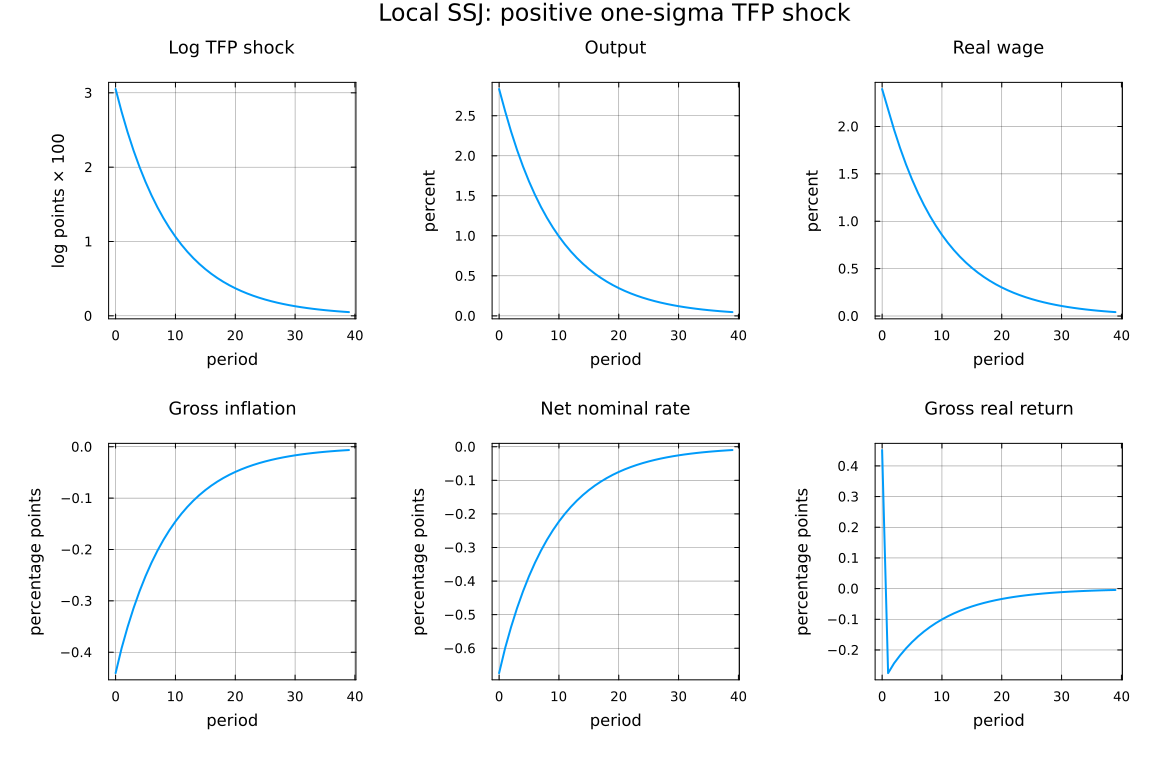

In [15]:
log_tfp_shock = params.sigma_z .* params.rho_z .^ (0:T-1)
monetary_shock = params.sigma_eta .* params.rho_eta .^ (0:T-1)
dE_tfp = vcat(log_tfp_shock, zeros(T))
dE_monetary = vcat(zeros(T), monetary_shock)

function linear_irf(ge, dE, ss, shock_path)
    return (
        shock=shock_path,
        inflation=ge.G_inflation_E * dE,
        wage=ge.G_wage_E * dE,
        output=ge.G_output_E * dE,
        consumption=ge.G_consumption_E * dE,
        gross_return=ge.G_return_E * dE,
        transfer=ge.G_transfer_E * dE,
        gross_nominal_rate=ge.G_nominal_E * dE,
    )
end

linear_tfp = linear_irf(ge, dE_tfp, ss, log_tfp_shock)
linear_monetary = linear_irf(ge, dE_monetary, ss, monetary_shock)

function plot_linear_hank_irf(irf, ss; title, shock_label)
    horizon = 40
    periods = 0:horizon-1
    panels = plot(layout=(2, 3), size=(1150, 760), plot_title=title, legend=false)
    plot!(panels[1], periods, 100 .* irf.shock[1:horizon];
        title=shock_label, ylabel="log points × 100", xlabel="period")
    plot!(panels[2], periods, 100 .* irf.output[1:horizon] ./ ss.output;
        title="Output", ylabel="percent", xlabel="period")
    plot!(panels[3], periods, 100 .* irf.wage[1:horizon] ./ ss.wage;
        title="Real wage", ylabel="percent", xlabel="period")
    plot!(panels[4], periods, 100 .* irf.inflation[1:horizon];
        title="Gross inflation", ylabel="percentage points", xlabel="period")
    plot!(panels[5], periods, 100 .* irf.gross_nominal_rate[1:horizon];
        title="Net nominal rate", ylabel="percentage points", xlabel="period")
    plot!(panels[6], periods, 100 .* irf.gross_return[1:horizon];
        title="Gross real return", ylabel="percentage points", xlabel="period")
    return panels
end

plot_linear_hank_irf(
    linear_tfp, ss;
    title="Local SSJ: positive one-sigma TFP shock",
    shock_label="Log TFP shock",
)


## 11) Nonlinear Deterministic Perfect-Foresight Responses

For the same shock paths, solve the nonlinear finite-horizon system

$$
H(u;E)=0,\qquad u=(\Pi,w,Y)\in\mathbb R^{3T}.
$$

Initialize with the local SSJ response,

$$
u^{(0)}=u_{ss}+G^{U,E}dE,
$$

and iterate with the steady-state Jacobian and a backtracking step,

$$
u^{(k+1)}=u^{(k)}-\lambda_k H_U^{-1}H(u^{(k)};E).
$$

Every residual evaluation recomputes the aggregate blocks, the household policy path backward, the distribution path forward, and all three equilibrium targets. The solver routines are kept in `SSJ_Function.jl`.


In [16]:
nonlinear_tfp = solve_ssj_hank_nonlinear(
    log_tfp_shock, zeros(T), ss, params, ge
)
nonlinear_monetary = solve_ssj_hank_nonlinear(
    zeros(T), monetary_shock, ss, params, ge
)

println("Nonlinear TFP iterations      = ", nonlinear_tfp.iterations)
println("Nonlinear TFP residual        = ", nonlinear_tfp.residual_norm)
println("Nonlinear monetary iterations = ", nonlinear_monetary.iterations)
println("Nonlinear monetary residual   = ", nonlinear_monetary.residual_norm)


Nonlinear TFP iterations      = 5
Nonlinear TFP residual        = 6.029790000638968e-10
Nonlinear monetary iterations = 3
Nonlinear monetary residual   = 3.246664048717207e-10


Five-sigma nonlinear transition checks
TFP:      iterations = 14, residual = 4.008e-10, max output gap = 2.308 pp
Monetary: iterations =  6, residual = 3.633e-11, max output gap = 0.113 pp


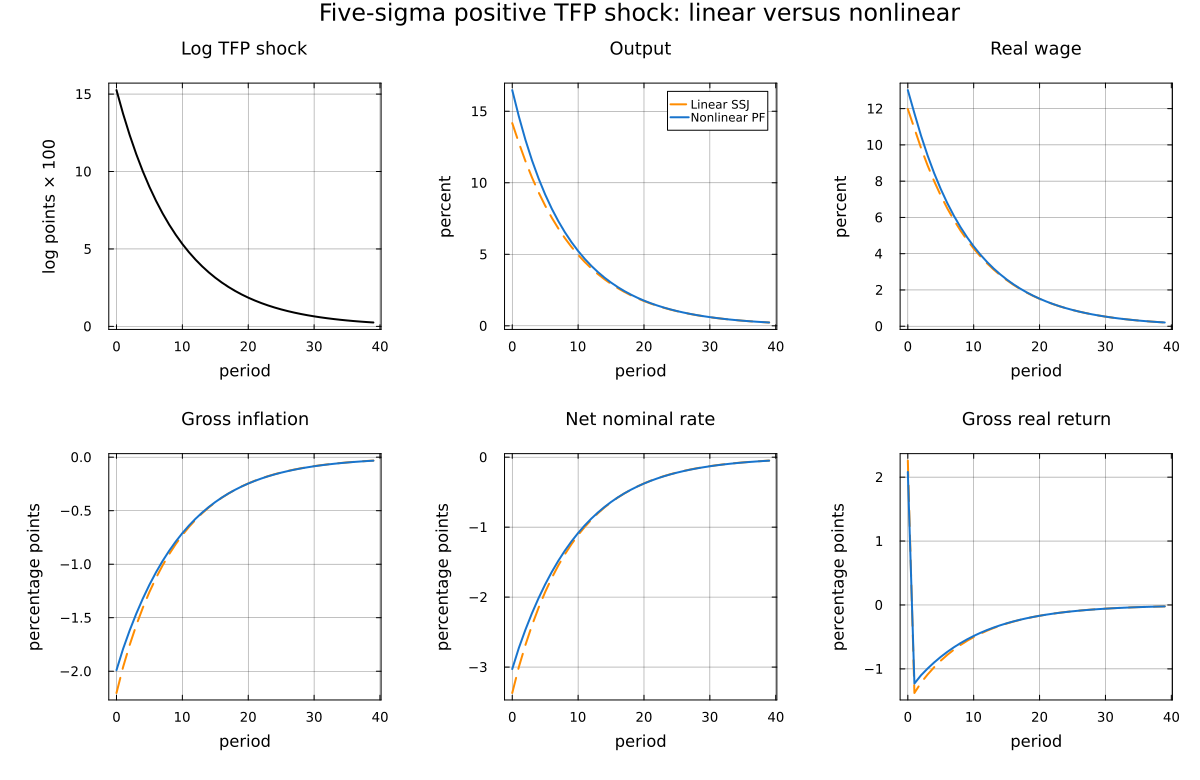

In [17]:
large_shock_scale = 5.0
large_log_tfp_shock = large_shock_scale .* log_tfp_shock
large_monetary_shock = large_shock_scale .* monetary_shock

linear_large_tfp = linear_irf(
    ge, vcat(large_log_tfp_shock, zeros(T)), ss, large_log_tfp_shock
)
linear_large_monetary = linear_irf(
    ge, vcat(zeros(T), large_monetary_shock), ss, large_monetary_shock
)

nonlinear_large_tfp_solution = solve_ssj_hank_nonlinear(
    large_log_tfp_shock, zeros(T), ss, params, ge; max_iterations=35
)
nonlinear_large_monetary_solution = solve_ssj_hank_nonlinear(
    zeros(T), large_monetary_shock, ss, params, ge; max_iterations=35
)
nonlinear_large_tfp = ssj_nonlinear_irf(
    nonlinear_large_tfp_solution, ss, large_log_tfp_shock
)
nonlinear_large_monetary = ssj_nonlinear_irf(
    nonlinear_large_monetary_solution, ss, large_monetary_shock
)

comparison_horizon = 40
tfp_output_gap = maximum(abs.(
    100 .* (nonlinear_large_tfp.output[1:comparison_horizon] .-
             linear_large_tfp.output[1:comparison_horizon]) ./ ss.output
))
monetary_output_gap = maximum(abs.(
    100 .* (nonlinear_large_monetary.output[1:comparison_horizon] .-
             linear_large_monetary.output[1:comparison_horizon]) ./ ss.output
))

@assert nonlinear_large_tfp_solution.residual_norm < 1e-8
@assert nonlinear_large_monetary_solution.residual_norm < 1e-8
println("Five-sigma nonlinear transition checks")
@printf("TFP:      iterations = %2d, residual = %.3e, max output gap = %.3f pp\n",
    nonlinear_large_tfp_solution.iterations,
    nonlinear_large_tfp_solution.residual_norm,
    tfp_output_gap)
@printf("Monetary: iterations = %2d, residual = %.3e, max output gap = %.3f pp\n",
    nonlinear_large_monetary_solution.iterations,
    nonlinear_large_monetary_solution.residual_norm,
    monetary_output_gap)

plot_hank_irf_comparison(
    linear_large_tfp, nonlinear_large_tfp, ss;
    title="Five-sigma positive TFP shock: linear versus nonlinear",
    shock_label="Log TFP shock",
    horizon=comparison_horizon,
)


Household statistics at the deterministic steady state
Mean quarterly labor income (model units)         0.866663
One-time transfer (model units)                  0.026000
Transfer / mean quarterly labor income            3.000%
Mass at b = 0                                     2.413%
Cash-balance HtM share                           26.689%
HtM share of aggregate consumption               24.070%
Baseline policy replay error                   3.429e-11

Finite-transfer cumulative MPCs
 horizon       mean     median        p90    share MPC>=0.5    HtM mean   non-HtM mean
   1 qtrs     0.0684     0.0553     0.0782          2.413%        0.1204        0.0495


   2 qtrs     0.1201     0.1088     0.1496          3.304%        0.1850        0.0964
   4 qtrs     0.2068     0.2085     0.2672          3.758%        0.2860        0.1779


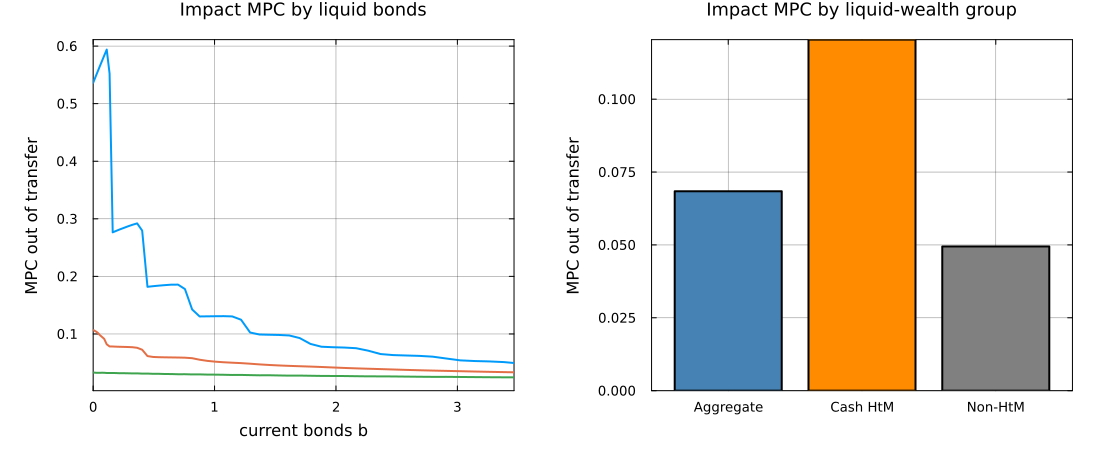

In [18]:
micro = ssj_mpc_and_htm_statistics(ss, params)

println("Household statistics at the deterministic steady state")
@printf("Mean quarterly labor income (model units)       %10.6f\n", micro.mean_labor_income)
@printf("One-time transfer (model units)                %10.6f\n", micro.transfer)
@printf("Transfer / mean quarterly labor income        %9.3f%%\n", 100micro.transfer_share)
@printf("Mass at b = 0                                 %9.3f%%\n", 100micro.constraint_share)
@printf("Cash-balance HtM share                        %9.3f%%\n", 100micro.cash_htm_share)
@printf("HtM share of aggregate consumption            %9.3f%%\n", 100micro.cash_htm_consumption_share)
@printf("Baseline policy replay error                  %10.3e\n", micro.replay_error)
println()
println("Finite-transfer cumulative MPCs")
println(" horizon       mean     median        p90    share MPC>=0.5    HtM mean   non-HtM mean")
for horizon in (1, 2, 4)
    m = micro.horizon_statistics[horizon]
    @printf(" %3d qtrs   %8.4f   %8.4f   %8.4f       %8.3f%%      %8.4f      %8.4f\n",
        horizon, m.mean, m.median, m.p90, 100m.high_mpc_share, m.htm_mean, m.non_htm_mean)
end

mpc_1 = micro.mpc_by_horizon[1]
p_mpc_assets = plot(
    ss.b_grid,
    mpc_1',
    title="Impact MPC by liquid bonds",
    xlabel="current bonds b",
    ylabel="MPC out of transfer",
    xlims=(0, min(4micro.mean_labor_income, ss.b_grid[end])),
    label=false,
)

impact = micro.horizon_statistics[1]
p_mpc_groups = bar(
    ["Aggregate", "Cash HtM", "Non-HtM"],
    [impact.mean, impact.htm_mean, impact.non_htm_mean],
    title="Impact MPC by liquid-wealth group",
    ylabel="MPC out of transfer",
    label=false,
    color=[:steelblue, :darkorange, :gray],
)

plot(p_mpc_assets, p_mpc_groups; layout=(1, 2), size=(1100, 460))


For the five-sigma TFP experiment, the maximum linear--nonlinear output gap over the first 40 quarters is $2.308$ percentage points: the nonlinear solution has a larger impact expansion than the local approximation. For the five-sigma monetary experiment, the corresponding maximum gap is $0.113$ percentage points, with the nonlinear solution implying a smaller impact contraction. The nonlinear residuals are $4.01\times10^{-10}$ and $3.63\times10^{-11}$, respectively, so these differences reflect nonlinear equilibrium terms rather than incomplete convergence.


## 12) Numerical and Terminal-Condition Checks

The final cell reports:

- steady-state goods and government-budget residuals;
- the constant-path residual;
- the fake-news versus direct-Jacobian error;
- nonlinear-solution residuals;
- mass at the upper bond node; and
- terminal distribution distances $\|D_T-D_{ss}\|_\infty$.

These checks verify the steady state, transition timing, Jacobian construction, nonlinear solves, grid support, and horizon length.


In [19]:
steady_path_error = maximum(abs.(vcat(
    steady_transition.nkpc,
    steady_transition.bond_market,
    steady_transition.labor_market,
    steady_transition.goods_market,
)))
steady_government_budget_error = abs(
    params.debt - ss.gross_return * params.debt - ss.transfer
)
fiscal_jacobian_error = maximum(
    maximum(abs.(
        getproperty(ge.macro_J, Symbol(:transfer_, input_name)) .+
        params.debt .* getproperty(
            ge.macro_J, Symbol(:gross_return_, input_name)
        )
    )) for input_name in (
        :inflation, :wage, :output, :log_tfp, :monetary
    )
)
ceiling_cutoff = params.bond_max - 1e-10
steady_ceiling_mass = sum(
    ss.distribution[ss.b_policy .>= ceiling_cutoff]
)
tfp_ceiling_mass = maximum(
    sum(
        nonlinear_tfp.out.distribution_path[t][
            nonlinear_tfp.out.b_policies[t] .>= ceiling_cutoff
        ]
    ) for t in 1:T
)
monetary_ceiling_mass = maximum(
    sum(
        nonlinear_monetary.out.distribution_path[t][
            nonlinear_monetary.out.b_policies[t] .>= ceiling_cutoff
        ]
    ) for t in 1:T
)
maximum_ceiling_mass = max(
    steady_ceiling_mass, tfp_ceiling_mass, monetary_ceiling_mass
)
tfp_terminal_distribution_error = maximum(abs.(
    nonlinear_tfp.out.distribution_path[end] .- ss.distribution
))
monetary_terminal_distribution_error = maximum(abs.(
    nonlinear_monetary.out.distribution_path[end] .- ss.distribution
))

println("Final numerical checks")
println(repeat("-", 58))
@printf("%-38s %16.3e\n", "steady-state goods residual", ss.goods_residual)
@printf("%-38s %16.3e\n", "government-budget residual", steady_government_budget_error)
@printf("%-38s %16.3e\n", "fiscal-Jacobian identity error", fiscal_jacobian_error)
@printf("%-38s %16.3e\n", "mass choosing upper bond node", maximum_ceiling_mass)
@printf("%-38s %16.3e\n", "steady-path maximum residual", steady_path_error)
@printf("%-38s %16.3e\n", "fake-news validation error", fake_news_error)
@printf("%-38s %16.3e\n", "nonlinear TFP residual", nonlinear_tfp.residual_norm)
@printf("%-38s %16.3e\n", "nonlinear monetary residual", nonlinear_monetary.residual_norm)
@printf("%-38s %16.3e\n", "TFP terminal distribution distance", tfp_terminal_distribution_error)
@printf("%-38s %16.3e\n", "monetary terminal distribution distance", monetary_terminal_distribution_error)

@assert abs(ss.bond_residual) < 1e-8
@assert abs(ss.labor_residual) < 1e-8
@assert abs(ss.goods_residual) < 1e-8
@assert steady_government_budget_error < 1e-12
@assert fiscal_jacobian_error < 1e-8
@assert maximum_ceiling_mass < 1e-10
@assert steady_path_error < 1e-6
@assert fake_news_error < 5e-5
@assert nonlinear_tfp.residual_norm < 1e-8
@assert nonlinear_monetary.residual_norm < 1e-8


Final numerical checks
----------------------------------------------------------
steady-state goods residual                  -1.533e-12
government-budget residual                    0.000e+00
fiscal-Jacobian identity error                0.000e+00
mass choosing upper bond node                5.177e-261
steady-path maximum residual                  6.668e-11
fake-news validation error                    1.013e-05
nonlinear TFP residual                        6.030e-10
nonlinear monetary residual                   3.247e-10
TFP terminal distribution distance            1.076e-06
monetary terminal distribution distance        2.042e-08


## 13) MPC and Hand-to-Mouth Statistics

### 13.1 Finite-Transfer MPC Experiment

Let the one-time transfer be

$$
x=0.03\,\overline y^{\ell},
\qquad
\overline y^{\ell}
=\sum_{e,b}D_{ss}(e,b)w_{ss}e n_{ss}(e,b).
$$

After the date-zero transfer, households return to the stationary policy. For horizon $H$,

$$
\operatorname{MPC}_H^x(e,b)
=
\frac{\mathcal C_H^x(e,b)-\mathcal C_H^0(e,b)}{x},
\qquad
\overline{\operatorname{MPC}}_H^x
=
\sum_{e,b}D_{ss}(e,b)\operatorname{MPC}_H^x(e,b),
$$

where $\mathcal C_H$ is cumulative consumption over $H$ quarters.

For hand-to-mouth households we use the cash-balance definition of Kaplan,
Violante, and Weidner (2014):

$$
b\leq\frac12 y^{\ell}(e,b),
\qquad
y^{\ell}(e,b)=w_{ss}e n_{ss}(e,b).
$$

We also report the exact mass at the borrowing limit, $\Pr(b=0)$. These are descriptive steady-state statistics, not equilibrium targets.


Household statistics at the deterministic steady state
Mean quarterly labor income (model units)         0.866663
One-time transfer (model units)                  0.026000
Transfer / mean quarterly labor income            3.000%
Mass at b = 0                                     2.413%
Cash-balance HtM share                           26.689%
HtM share of aggregate consumption               24.070%
Baseline policy replay error                   3.429e-11

Finite-transfer cumulative MPCs
 horizon       mean     median        p90    share MPC>=0.5    HtM mean   non-HtM mean
   1 qtrs     0.0684     0.0553     0.0782          2.413%        0.1204        0.0495
   2 qtrs     0.1201     0.1088     0.1496          3.304%        0.1850        0.0964
   4 qtrs     0.2068     0.2085     0.2672          3.758%        0.2860        0.1779


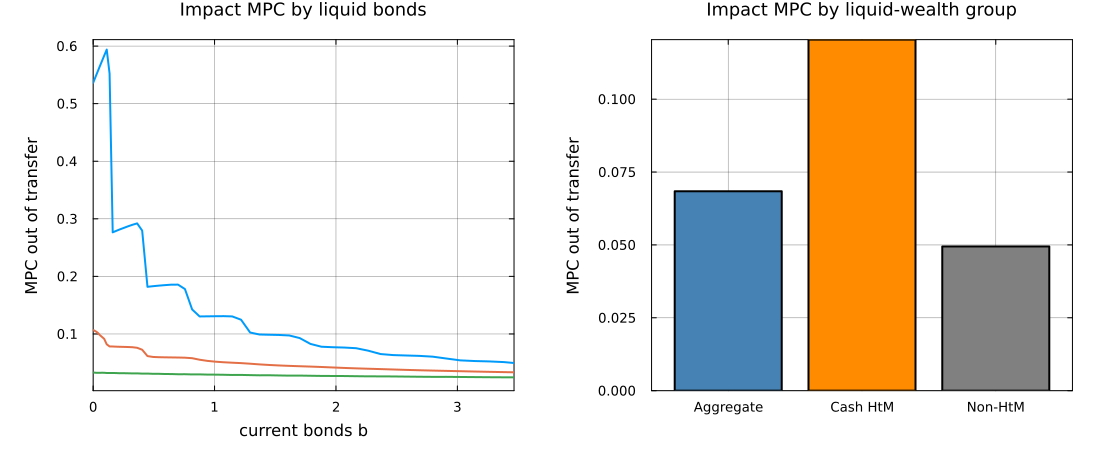

In [20]:
micro = ssj_mpc_and_htm_statistics(ss, params)

println("Household statistics at the deterministic steady state")
@printf("Mean quarterly labor income (model units)       %10.6f\n", micro.mean_labor_income)
@printf("One-time transfer (model units)                %10.6f\n", micro.transfer)
@printf("Transfer / mean quarterly labor income        %9.3f%%\n", 100micro.transfer_share)
@printf("Mass at b = 0                                 %9.3f%%\n", 100micro.constraint_share)
@printf("Cash-balance HtM share                        %9.3f%%\n", 100micro.cash_htm_share)
@printf("HtM share of aggregate consumption            %9.3f%%\n", 100micro.cash_htm_consumption_share)
@printf("Baseline policy replay error                  %10.3e\n", micro.replay_error)
println()
println("Finite-transfer cumulative MPCs")
println(" horizon       mean     median        p90    share MPC>=0.5    HtM mean   non-HtM mean")
for horizon in (1, 2, 4)
    m = micro.horizon_statistics[horizon]
    @printf(" %3d qtrs   %8.4f   %8.4f   %8.4f       %8.3f%%      %8.4f      %8.4f\n",
        horizon, m.mean, m.median, m.p90, 100m.high_mpc_share, m.htm_mean, m.non_htm_mean)
end

mpc_1 = micro.mpc_by_horizon[1]
p_mpc_assets = plot(
    ss.b_grid,
    mpc_1',
    title="Impact MPC by liquid bonds",
    xlabel="current bonds b",
    ylabel="MPC out of transfer",
    xlims=(0, min(4micro.mean_labor_income, ss.b_grid[end])),
    label=false,
)

impact = micro.horizon_statistics[1]
p_mpc_groups = bar(
    ["Aggregate", "Cash HtM", "Non-HtM"],
    [impact.mean, impact.htm_mean, impact.non_htm_mean],
    title="Impact MPC by liquid-wealth group",
    ylabel="MPC out of transfer",
    label=false,
    color=[:steelblue, :darkorange, :gray],
)

plot(p_mpc_assets, p_mpc_groups; layout=(1, 2), size=(1100, 460))


The transfer experiment is partial equilibrium: only date-zero cash on hand changes, while prices and subsequent stationary policies remain fixed. The HtM and non-HtM averages show how the impact MPC varies across the liquid-wealth distribution.


### 13.2 An Illustrative Parameter Experiment

To see the model's internal mechanics, vary government debt over

$$
B\in\{0.6,0.8,\ldots,2.4\}.
$$

For each $B$, set $\Pi_{ss}=1$, fix the annual real rate at $2\%$, and solve for
$\beta$ and $Y$ so that the bond and labor markets clear. We then report

$$
\frac{B}{4Y},\qquad s_{HtM}^{cash},\qquad \overline{\operatorname{MPC}}_1.
$$

The fixed rate and transfer size are transparent normalizations for this sweep; the exercise is a sensitivity analysis, not a calibration to another paper. For visual reference, the dashed data lines mark liquid wealth equal to $26\%$ of annual output, an HtM share of $30\%$, and a one-quarter transfer MPC of $0.16$.


In [21]:
# Reusable parameter-sweep routines are defined in src/SSJ_Function.jl.
trial_annual_real_rate = 0.02
trial_transfer_share = 0.03


0.03

In [22]:
trial_debt_grid = collect(0.6:0.2:2.4)
trial_frontier = NamedTuple[]
failed_trial_points = NamedTuple[]
for debt in trial_debt_grid
    try
        push!(
            trial_frontier,
            ssj_fixed_rate_candidate(
                debt,
                params;
                nB=100,
                annual_real_rate=trial_annual_real_rate,
                transfer_share=trial_transfer_share,
            ),
        )
    catch error_object
        push!(failed_trial_points, (
            debt=debt,
            error=sprint(showerror, error_object),
        ))
    end
end
isempty(trial_frontier) && error("Every parameter-sweep point failed")

current_moments = (
    liquid=params.debt / (4ss.output),
    htm=micro.cash_htm_share,
    mpc=micro.horizon_statistics[1].mean,
)

println("Illustrative fixed-rate parameter sweep")
println(repeat("-", 92))
@printf("%-16s %8s %8s %12s %12s %12s\n",
    "case", "beta", "B", "liquid/Y", "HtM", "impact MPC")
println(repeat("-", 92))
@printf("%-16s %8.5f %8.2f %12.3f %12.3f %12.3f\n",
    "baseline", params.beta, params.debt,
    current_moments.liquid, current_moments.htm, current_moments.mpc)
for point in trial_frontier
    @printf("%-16s %8.5f %8.2f %12.3f %12.3f %12.3f\n",
        "fixed-rate", point.beta, point.debt,
        point.liquid, point.htm, point.mpc)
end
println(repeat("-", 92))
@printf("Fixed annual real rate: %.2f%%\n", 100trial_annual_real_rate)
@printf("Maximum trial equilibrium residual: %.3e\n",
    maximum(getproperty.(trial_frontier, :maximum_residual)))
@printf("Failed trial points: %d of %d\n",
    length(failed_trial_points), length(trial_debt_grid))


Illustrative fixed-rate parameter sweep
--------------------------------------------------------------------------------------------
case                 beta        B     liquid/Y          HtM   impact MPC
--------------------------------------------------------------------------------------------
baseline          0.97500     2.00        0.518        0.267        0.068


fixed-rate        0.97834     0.60        0.157        0.728        0.156
fixed-rate        0.98180     0.80        0.208        0.669        0.124
fixed-rate        0.98422     1.00        0.260        0.616        0.110
fixed-rate        0.98598     1.20        0.312        0.562        0.089
fixed-rate        0.98725     1.40        0.364        0.506        0.083
fixed-rate        0.98829     1.60        0.415        0.454        0.076
fixed-rate        0.98912     1.80        0.467        0.342        0.069
fixed-rate        0.98981     2.00        0.518        0.217        0.063
fixed-rate        0.99038     2.20        0.570        0.165        0.058
fixed-rate        0.99086     2.40        0.621        0.138        0.054
--------------------------------------------------------------------------------------------
Fixed annual real rate: 2.00%
Maximum trial equilibrium residual: 1.135e-07
Failed trial points: 0 of 10


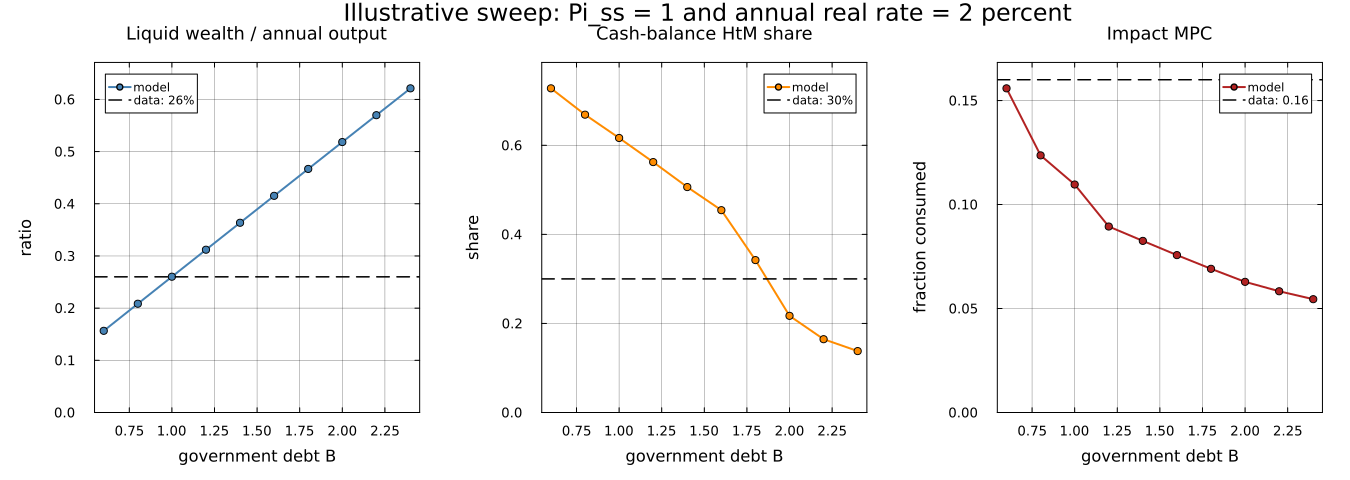

In [23]:
frontier_debt = getproperty.(trial_frontier, :debt)
frontier_liquid = getproperty.(trial_frontier, :liquid)
frontier_htm = getproperty.(trial_frontier, :htm)
frontier_mpc = getproperty.(trial_frontier, :mpc)

data_liquid_to_annual_output = 0.26
data_htm_share = 0.30
data_impact_mpc = 0.16

p_sweep_liquid = plot(
    frontier_debt,
    frontier_liquid;
    marker=:circle,
    color=:steelblue,
    label="model",
    title="Liquid wealth / annual output",
    xlabel="government debt B",
    ylabel="ratio",
    ylims=(0, maximum(frontier_liquid) * 1.08),
    legend=:topleft,
)
hline!(
    p_sweep_liquid,
    [data_liquid_to_annual_output];
    color=:black,
    linestyle=:dash,
    linewidth=1.5,
    label="data: 26%",
)

p_sweep_htm = plot(
    frontier_debt,
    frontier_htm;
    marker=:circle,
    color=:darkorange,
    label="model",
    title="Cash-balance HtM share",
    xlabel="government debt B",
    ylabel="share",
    ylims=(0, maximum(frontier_htm) * 1.08),
    legend=:topright,
)
hline!(
    p_sweep_htm,
    [data_htm_share];
    color=:black,
    linestyle=:dash,
    linewidth=1.5,
    label="data: 30%",
)

p_sweep_mpc = plot(
    frontier_debt,
    frontier_mpc;
    marker=:circle,
    color=:firebrick,
    label="model",
    title="Impact MPC",
    xlabel="government debt B",
    ylabel="fraction consumed",
    ylims=(0, maximum(frontier_mpc) * 1.08),
    legend=:topright,
)
hline!(
    p_sweep_mpc,
    [data_impact_mpc];
    color=:black,
    linestyle=:dash,
    linewidth=1.5,
    label="data: 0.16",
)

plot(
    p_sweep_liquid,
    p_sweep_htm,
    p_sweep_mpc;
    layout=(1, 3),
    size=(1350, 480),
    plot_title="Illustrative sweep: Pi_ss = 1 and annual real rate = 2 percent",
)


The sweep isolates the one-asset mechanism. Lower debt reduces average liquid wealth, puts more households near the borrowing limit, and raises the impact MPC. Higher debt produces the opposite movement. The experiment is used only to understand parameter sensitivity; the baseline calibration remains unchanged for the SSJ solution below.


## 14) Consumption-Channel Decomposition

### 14.1 Monetary easing

Consider a one-standard-deviation monetary easing, $d\eta_t=-\sigma_\eta\rho_\eta^t$. Once general equilibrium determines the paths $dR$, $dw$, $dd$, and $dT$, the household Jacobians give

$$
dC
=
\underbrace{J_{C,R}dR}_{\text{direct liquid-return effect}}
+
\underbrace{J_{C,w}dw+J_{C,d}dd+J_{C,T}dT}_{\text{indirect general-equilibrium effects}}.
$$

Each term is a counterfactual derivative: vary one household input along its equilibrium path while holding the other household inputs at steady state. The $R$ term is the direct effect because the real return enters the household budget constraint directly. The wage, dividend, and fiscal-transfer terms are indirect because their paths are generated by equilibrium feedback. This one-asset model has no separate illiquid-return channel; distributed firm profits appear through $d$, while the government interest-saving channel appears through $T$. Because this is a first-order decomposition, the four components must add exactly to the linear consumption IRF.


In [24]:
monetary_easing = -monetary_shock
dE_monetary_easing = vcat(zeros(T), monetary_easing)
consumption_channels = ssj_hank_consumption_channel_decomposition(
    ge, dE_monetary_easing
)

consumption_channels.closure_error < 1e-10 ||
    error("Consumption channels do not add up")

monetary_channel_summary = print_hank_consumption_channel_summary(
    consumption_channels, ss; label="one-sigma monetary easing"
)


Consumption decomposition: 

one-sigma monetary easing
  total impact             0.11884% of steady-state C
  direct: real return     0.03806% (   32.03% of total)
  indirect: wage          0.08135% (   68.45% of total)
  indirect: dividend     -0.02582% (  -21.73% of total)
  indirect: transfer      0.02526% (   21.25% of total)
  all indirect            0.08078% (   67.97% of total)
  maximum adding-up error: 1.084e-18


(impacts = (direct_return = 0.0003665394492822531, wage = 0.0007833824431640274, dividend = -0.0002486843292645456, transfer = 0.0002432223101802206, indirect = 0.0007779204240797023, total = 0.0011444598733619566), shares = (direct_return = 32.02728709094095, wage = 68.44997027836102, dividend = -21.72940572691399, transfer = 21.252148357611926, indirect = 67.97271290905894, total = 100.0))

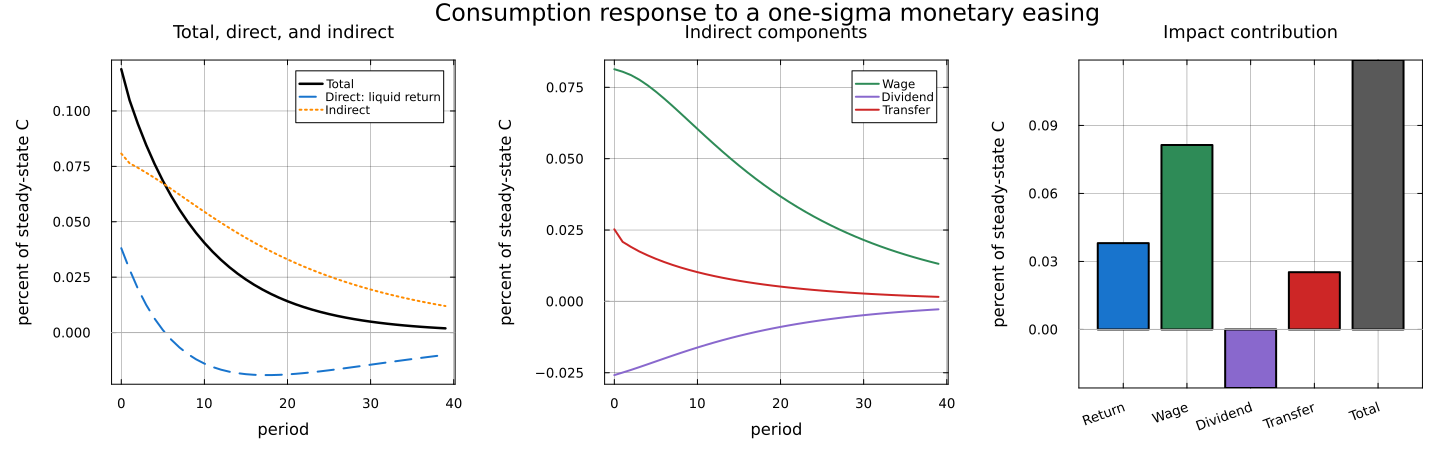

In [25]:
plot_hank_consumption_channels(
    consumption_channels,
    ss;
    horizon=40,
    title="Consumption response to a one-sigma monetary easing",
)


At impact, the monetary easing raises consumption by $0.11884\%$ of steady-state consumption. The direct real-return channel contributes $0.03806\%$, or $32.03\%$ of the total response. The indirect channels contribute the remaining $67.97\%$: higher wages add $0.08135\%$, the fiscal transfer adds $0.02526\%$, and lower distributed profits subtract $0.02582\%$. The maximum adding-up error is $1.1\times10^{-18}$, so the four counterfactual derivatives reproduce the total linear consumption response numerically.

The direct path is a dynamic counterfactual, not the contemporaneous derivative of consumption with respect to the current real return. At every date,

$$
dC_t^{R}=\sum_{s=0}^{T-1}J_{C,R}(t,s)dR_s.
$$

The initial fall in the real-return path induces households to bring consumption forward, giving a positive impact response. Later, lower accumulated assets and lower interest income make households rebuild savings, so the direct component turns negative before converging back to zero. In this direct counterfactual the fiscal transfer is held fixed. The separate positive transfer channel captures the fact that the rule $T_t=(1-R_t)B$ returns the government's lower interest expense to households.


### 14.2 Positive TFP shock

Now apply the same decomposition to a one-standard-deviation positive productivity shock,

$$
d\log z_t=\sigma_z\rho_z^t.
$$

General equilibrium again determines the household-input paths $(dR,dw,dd,dT)$. Holding the other household inputs fixed in turn gives the direct real-return contribution and the three indirect income contributions.


In [26]:
tfp_consumption_channels = ssj_hank_consumption_channel_decomposition(
    ge, dE_tfp
)

tfp_consumption_channels.closure_error < 1e-10 ||
    error("TFP consumption channels do not add up")

tfp_channel_summary = print_hank_consumption_channel_summary(
    tfp_consumption_channels, ss; label="positive one-sigma TFP shock"
)


Consumption decomposition: positive one-sigma TFP shock
  total impact             2.59889% of steady-state C
  direct: real return     1.15172% (   44.32% of total)
  indirect: wage          1.16195% (   44.71% of total)
  indirect: dividend      0.19650% (    7.56% of total)
  indirect: transfer      0.08871% (    3.41% of total)
  all indirect            1.44716% (   55.68% of total)
  maximum adding-up error: 1.388e-17


(impacts = (direct_return = 0.011091195886405773, wage = 0.011189652920157684, dividend = 0.001892301909131482, transfer = 0.0008543255876965365, indirect = 0.013936280416985703, total = 0.025027476303391465), shares = (direct_return = 44.316077865600896, wage = 44.709473638144566, dividend = 7.560897815634158, transfer = 3.4135506806204314, indirect = 55.683922134399154, total = 100.0))

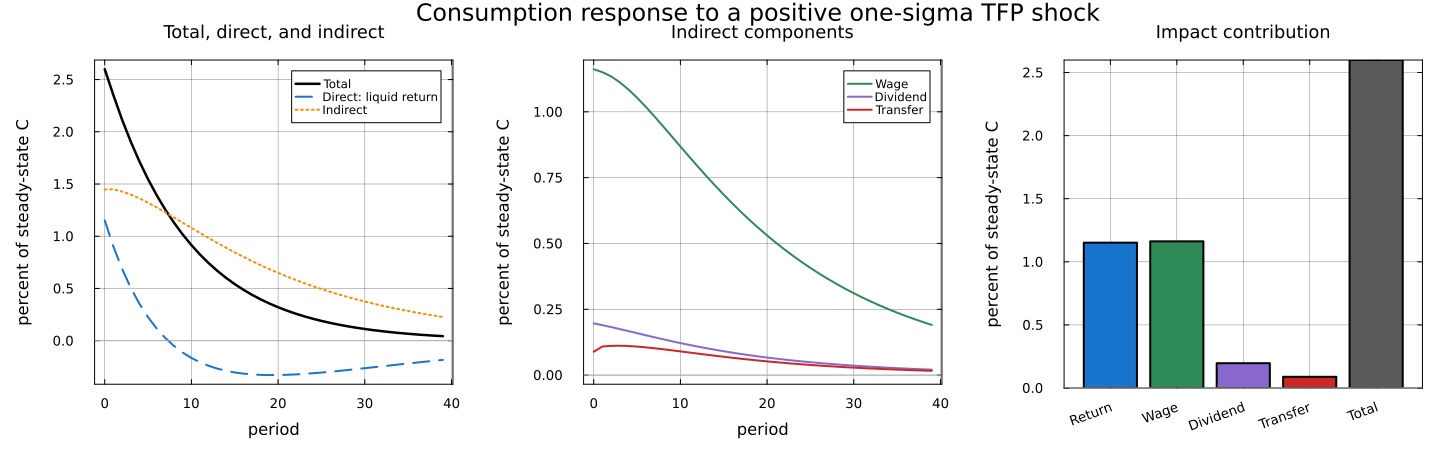

In [27]:
plot_hank_consumption_channels(
    tfp_consumption_channels,
    ss;
    horizon=40,
    title="Consumption response to a positive one-sigma TFP shock",
)


At impact, the positive TFP shock raises consumption by $2.59889\%$ of steady-state consumption. The real-return channel contributes $1.15172\%$, or $44.32\%$ of the total. The wage channel contributes $1.16195\%$ ($44.71\%$), while dividends and fiscal transfers contribute $0.19650\%$ ($7.56\%$) and $0.08871\%$ ($3.41\%$), respectively. Thus the wage path is now the largest individual channel by a small margin, while the three indirect income channels together account for $55.68\%$ of the impact response. The maximum adding-up error is $1.4\times10^{-17}$.


## 15) Mortality and Newborn Entry: An Independent Robustness Experiment

### 15.1 Motivation and mechanism

Section 13 showed the central one-asset calibration tension. Changing government bond supply $B$ or household patience $\beta$ moves the mass of low-liquid-wealth households and the MPC in the same direction, but the baseline model cannot match both moments simultaneously while retaining a reasonably large supply of liquid government debt. This section holds the baseline calibration fixed and asks whether an additional *flow into zero wealth* can relax that tension.

Following the mortality--newborn mechanism used by Kaplan, Moll, and Violante (2018), a household dies each quarter with exogenous probability

$$
\zeta=\frac{1}{180},
$$

which corresponds to an expected lifetime of roughly $45$ years. A deceased household exits. A newborn enters with $b=0$, draws efficiency $e$ from the invariant distribution $\pi_e$, and does not inherit the deceased household's wealth. A perfect annuity market redistributes the assets of deceased households to survivors through a mortality credit. Thus death creates a flow of zero-wealth newborns without destroying aggregate bond payoffs.

For a stationary price vector $(R^b,w,d,T)$, the living household solves

$$
V(b,e)=\max_{c,n,b'}\left\{
\log c-\frac{n^2}{2}
+\beta(1-\zeta)\sum_{e'}P_e(e,e')V(b',e')
\right\}
$$

subject to

$$
c+b'=\frac{R^b}{1-\zeta}b+wen+d+T,
\qquad b'\geq0.
$$

The continuation value is discounted by survival, while a survivor earns the actuarially fair gross return $R^b/(1-\zeta)$. These adjustments cancel in the unconstrained Euler equation,

$$
\frac{1}{c}
=\beta(1-\zeta)\frac{R^b}{1-\zeta}
\sum_{e'}P_e(e,e')\frac{1}{c(e',b')}
=\beta R^b\sum_{e'}P_e(e,e')\frac{1}{c(e',b')}.
$$

Mortality nevertheless changes cash on hand and the stationary distribution. Given the saving policy $g_b(e,b)$, the distribution of living households evolves according to

$$
D_{t+1}
=(1-\zeta)\,\mathcal P(g_b,P_e)'D_t
+\zeta\,\delta_{b=0}\otimes\pi_e.
$$

The first term advances survivors; the second inserts newborns at zero bonds. The code applies the annuity adjustment only in the household budget and applies survival only once in the distribution transition. Every step verifies $\sum_{e,b}D_{t+1}(e,b)=1$.

This is deliberately an extension rather than a new baseline. All earlier SSJ results remain unchanged.

### 15.2 Partial- and general-equilibrium experiments

We compare

$$
\zeta\in\left\{0,\frac{1}{360},\frac{1}{180},\frac{1}{120}\right\}.
$$

No other structural parameter is recalibrated. The fixed-price experiment holds $(R^b,w,d,T)$ at their baseline values and isolates the household mortality--newborn mechanism. Its asset-market residual is an outcome. The general-equilibrium experiment keeps government debt at $B=2$ and re-solves inflation, the real wage, and output so that the NKPC, bond market, and labor market clear. The solution at $\zeta=0$ is a regression test against the original baseline.

In [28]:
mortality_grid = [0.0, 1 / 360, 1 / 180, 1 / 120]

mortality_experiment = run_ssj_mortality_experiment(
    ss,
    grids,
    params,
    mortality_grid;
    transfer_share=0.03,
)

baseline_mortality_ge = mortality_experiment.general_equilibrium[1]
@printf("zeta=0 regression: max GE residual       %.3e\n",
    baseline_mortality_ge.maximum_residual)
@printf("zeta=0 regression: max price/output gap  %.3e\n",
    maximum(abs.([
        baseline_mortality_ge.inflation - ss.inflation,
        baseline_mortality_ge.wage - ss.wage,
        baseline_mortality_ge.output - ss.output,
    ])))
@printf("maximum probability-mass error           %.3e\n",
    maximum(result.moments.mass_error
        for result in mortality_experiment.general_equilibrium))
@printf("maximum targeted GE residual             %.3e\n",
    maximum(result.maximum_residual
        for result in mortality_experiment.general_equilibrium))
@printf("maximum untargeted goods residual         %.3e\n",
    maximum(abs(result.goods_residual)
        for result in mortality_experiment.general_equilibrium))
@printf("maximum distribution fixed-point error    %.3e\n",
    maximum(result.moments.distribution_error
        for result in mortality_experiment.general_equilibrium))
@printf("maximum policy replay error               %.3e\n",
    maximum(result.moments.policy_replay_error
        for result in mortality_experiment.general_equilibrium))

zeta=0 regression: max GE residual       6.667e-11
zeta=0 regression: max price/output gap  0.000e+00
maximum probability-mass error           2.220e-16
maximum targeted GE residual             6.667e-11
maximum untargeted goods residual         1.533e-12
maximum distribution fixed-point error    9.742e-14
maximum policy replay error               3.934e-11


### 15.3 Wealth, HtM, MPC, and numerical moments

The table keeps distinct objects separate:

- $\Pr(b=0)$ is the strict zero-bond atom;
- the data-window HtM share uses $|b|\leq\tfrac12\,wen$, the same cash-balance definition used in Section 13;
- the borrowing-constraint share is $\Pr(b=b_{\min})$;
- $\Pr(b<0)$ records indebted households;
- impact and annual MPCs come from the same finite-transfer numerical experiment used earlier, with future consumption weighted by survival;
- asset demand is the mean saving policy $\int g_b(e,b)\,dD(e,b)$, the object that must equal government debt $B$.

Because this notebook imposes $b_{\min}=0$, strict zero wealth and the borrowing constraint coincide, and negative liquid wealth is mechanically zero. Reporting all three makes the limitation explicit instead of treating indebted households as HtM.

In [29]:
print_ssj_mortality_comparison(mortality_experiment)

Fixed baseline prices (partial equilibrium)
-------------------------------------------------------------------------------------------------------------------------------------------------


mortality   life yrs    Pr(b=0)   data HtM    at bmin    Pr(b<0)  impact MPC  annual MPC  asset dem. asset resid.  mass error
-------------------------------------------------------------------------------------------------------------------------------------------------


0           infinity     2.413%    26.689%     2.413%     0.000%      0.0684      0.2068     2.00000    6.667e-11   0.000e+00
1/360           90.0     2.843%    30.788%     2.843%     0.000%      0.0711      0.2127     1.93726   -6.274e-02   0.000e+00
1/180           45.0     3.266%    34.780%     3.266%     0.000%      0.0738      0.2184     1.87586   -1.241e-01   0.000e+00
1/120           30.0     3.681%    38.524%     3.681%     0.000%      0.0763      0.2238     1.81589   -1.841e-01   0.000e+00
-------------------------------------------------------------------------------------------------------------------------------------------------

Prices re-solved to clear markets (general equilibrium)
-------------------------------------------------------------------------------------------------------------------------------------------------
mortality   life yrs    Pr(b=0)   data HtM    at bmin    Pr(b<0)  impact MPC  annual MPC  asset dem. asset resid.  mass error
--------------------

0              0.99466202     1.01983124     0.89867263     0.96438128
1/360          0.99507060     1.02004067     0.89877372     0.96437386
1/180          0.99549576     1.02025857     0.89887901     0.96437833
1/120          0.99594357     1.02048801     0.89899000     0.96439764
----------------------------------------------------------------------------------


### 15.4 Distributional effects

The first two panels report probability mass at each bond-grid node, with a separate enlargement around $b=0$; the third reports the CDF. The grid is quadratic, so node masses should be read jointly with the CDF rather than as a continuous density.

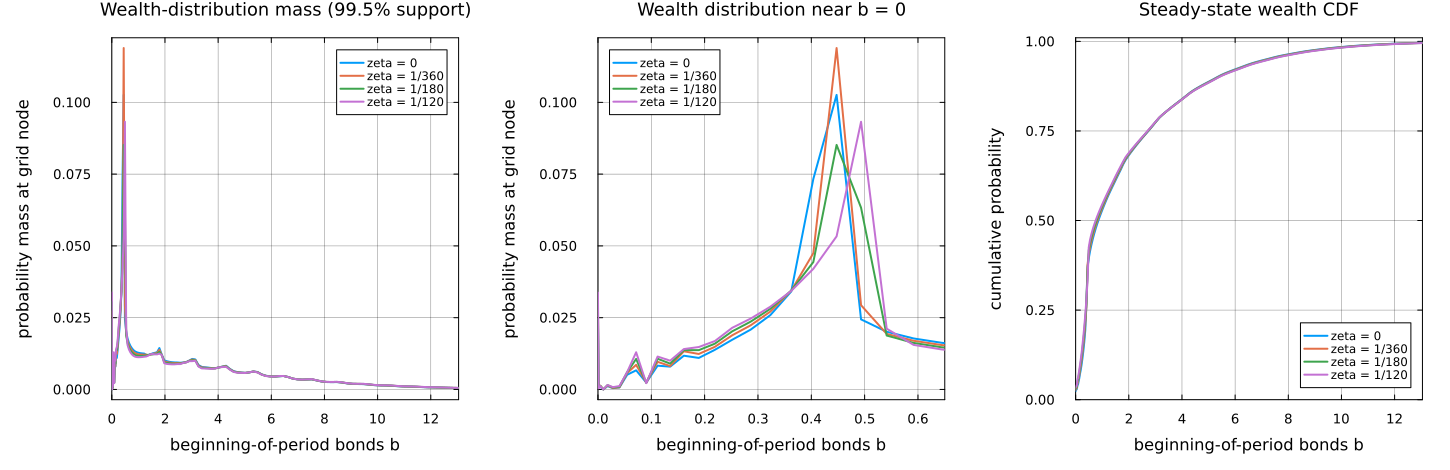

In [30]:
plot_ssj_mortality_distributions(
    mortality_experiment.general_equilibrium,
    grids,
)

**Takeaway.** The mortality--newborn mechanism does move the household moments in the intended direction by continuously adding new households at $b=0$. In general equilibrium, the KMV value $\zeta=1/180$ raises the HtM share only from $26.689\%$ to $26.863\%$ and the impact MPC from $0.0684$ to $0.0699$. Thus the mechanism helps at the margin, but its quantitative effect is small after equilibrium prices adjust; it is unlikely to be the main mechanism needed to resolve the one-asset model's joint HtM--MPC calibration tension.